# From Cells to Selves: the origin of reward, agency and goal-directed behaviour

### A computational companion to sixteen papers

This notebook asks one question in eleven experiments:

> **Reward, agency and goal-directedness are abstractions we impose on organisms. Do they
> pick out the same thing in a bacterium, a rodent and a deep RL agent — and if not, how
> did the function that these words name change over evolution?**

The strategy throughout is: build one substrate, define *several different "rewards" on it*,
and see which abstraction the organism's behaviour actually licenses.

| Part | Question | Papers |
|---|---|---|
| 1 | Four objectives, one world: what does each kind of "reward" produce? | MOP, empowerment, free energy, intrinsic motivation |
| 2 | What happens when *evolution* optimises each objective? | Markov Brains / degeneracy |
| 3 | **Is the reward hypothesis true?** A runnable falsification test | Reward is Enough; Settling the Reward Hypothesis; Three Dogmas |
| 4 | Homeostasis and interoception as the origin of value | interoceptive AI; homeostatic RL |
| 5 | Goal-directed behaviour *before* reward: endotaxis | Endotaxis |
| 6 | Agency at which scale? Cells vs tissue, with real PyPhi | Levin: collective intelligence, agency/part-whole, regulative development |
| 7 | The same tests on **97 real evolved Markov Brains** | From Function to Implementation |
| 9 | Scaling the test up: tasks of controlled permissiveness | Settling the Reward Hypothesis |
| 10 | Reward-expressibility along a **line of descent** | Three Dogmas; interoceptive AI |
| 11 | Which objective actually rationalises evolved behaviour? | Guest & Martin (metatheory) |
| 8 | Synthesis: the evolutionary arc of "reward" | all |

**Runtime:** roughly 12–15 minutes end to end on a free Colab CPU. Every part is independent —
you can run Part 3 alone if that is the part you care about.

---
### The one idea you should take from this notebook

A *behaviour* can almost always be redescribed as reward maximisation (this is the vacuity
result — Part 3). A **task**, understood as the *set* of behaviours that count as acceptable,
very often cannot. Which of the two you are talking about changes as organisms acquire internal
state — and, as Parts 4, 7 and 10 show, it changes in the direction that makes the reward
abstraction *worse*, not better, as organisms get more capable.

In [ ]:
#@title Setup (run me first)
import numpy as np, itertools, json, os, glob, zipfile, warnings
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import linprog
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white",
})
C = {"R": "#c0392b", "MOP": "#2471a3", "MPOW": "#1e8449",
     "EFE": "#8e44ad", "surv": "#797d7f", "rand": "#aeb6bf"}
RNG = np.random.default_rng(0)
print("ready")

ready


---
# Part 1 — Four "rewards", one world

We build a single gridworld with an **internal energy variable** `u`. The agent dies when
`u = 0`, and death is an absorbing state with value zero. Everything below is defined on this
one world, so any behavioural difference is attributable to the *objective*, not the
environment.

The four objectives are the ones your papers put on the table:

| | objective | where it comes from |
|---|---|---|
| **R** | maximise discounted scalar reward (food) | classical RL, *Reward is Enough* |
| **MOP** | maximise occupancy of future action-state path space | *Complex behavior from intrinsic motivation…* |
| **MPOW** | maximise *n*-step empowerment (channel capacity action→future state) | *Approximation of Empowerment*; *Information is Power* |
| **EFE** | minimise expected free energy | *The free-energy principle* |

Note what MOP, MPOW and EFE have in common and how they differ from R: none of them is a signal
*delivered by the environment*. They are all functionals of the agent–environment coupling. This
distinction will matter a great deal in Part 3.

In [ ]:
#@title Core library: the world and the four solvers
"""
core_env.py -- a single substrate on which every "reward" can be defined.

LifeGrid: a gridworld with an INTERNAL energy variable u (interoception).
The agent dies at u = 0 (absorbing, zero value). This single environment is
shared by all four objectives (R, MOP, MPOW, EFE) so that any behavioural
difference is attributable to the objective, not the world.

Design follows Ramirez-Ruiz et al. (occupancy_max_paper) but reimplemented in
numpy so that everything is exact, fast and inspectable.
"""
import numpy as np
import itertools

ACTIONS = [(0, 1), (0, -1), (1, 0), (-1, 0)]      # E, W, S, N
ACTION_NAMES = ["E", "W", "S", "N"]


class LifeGrid:
    def __init__(self, walls, food, F=10, food_gain=4, gamma=0.99):
        """
        walls : (H,W) bool array, True = impassable
        food  : (H,W) int array, energy gained on entering that cell
        F     : max energy (u in 0..F); u=0 is death
        """
        self.walls = np.asarray(walls, dtype=bool)
        self.food = np.asarray(food, dtype=int)
        self.H, self.W = self.walls.shape
        self.F = F
        self.food_gain = food_gain
        self.gamma = gamma

        self.cells = [(i, j) for i in range(self.H) for j in range(self.W)
                      if not self.walls[i, j]]
        self.cell_id = {c: k for k, c in enumerate(self.cells)}
        self.nC = len(self.cells)
        self.nU = F + 1                      # u = 0 .. F
        self.nS = self.nC * self.nU
        self.nA = len(ACTIONS)
        self._build()

    # ---- indexing -------------------------------------------------------
    def sid(self, cell, u):
        return self.cell_id[cell] * self.nU + u

    def decode(self, s):
        c, u = divmod(s, self.nU)
        return self.cells[c], u

    def is_dead(self, s):
        return (s % self.nU) == 0

    # ---- dynamics -------------------------------------------------------
    def _build(self):
        """Deterministic transition table T[s,a] -> s'. Dead states absorb."""
        T = np.zeros((self.nS, self.nA), dtype=np.int64)
        food_intake = np.zeros((self.nS, self.nA))
        for c, (i, j) in enumerate(self.cells):
            for u in range(self.nU):
                s = c * self.nU + u
                if u == 0:                                  # death: absorbing
                    T[s, :] = s
                    continue
                for a, (di, dj) in enumerate(ACTIONS):
                    ni, nj = i + di, j + dj
                    if not (0 <= ni < self.H and 0 <= nj < self.W) or self.walls[ni, nj]:
                        ni, nj = i, j                       # bump into wall
                    gain = self.food_gain if self.food[ni, nj] > 0 else 0
                    nu = min(self.F, u - 1 + gain)
                    nu = max(0, nu)
                    T[s, a] = self.cell_id[(ni, nj)] * self.nU + nu
                    food_intake[s, a] = gain
        self.T = T
        self.food_intake = food_intake
        self.alive = np.array([(s % self.nU) != 0 for s in range(self.nS)])

    def rollout(self, policy, s0, n_steps, rng):
        """policy: (nS,nA) stochastic. Returns states, actions (stops at death)."""
        s = s0
        S, A = [s], []
        for _ in range(n_steps):
            if self.is_dead(s):
                break
            p = policy[s]
            a = rng.choice(self.nA, p=p / p.sum())
            s = self.T[s, a]
            A.append(a)
            S.append(s)
        return np.array(S), np.array(A)


# =====================================================================
# Objective 1: R  -- extrinsic scalar reward (classic RL)
# =====================================================================
def solve_R(env, reward=None, n_iter=2000, tol=1e-8, beta=None):
    """Value iteration on a designer-specified scalar reward.
    Default reward = food intake. Death is absorbing with value 0."""
    R = env.food_intake if reward is None else reward
    V = np.zeros(env.nS)
    for _ in range(n_iter):
        Q = R + env.gamma * V[env.T]
        Q[~env.alive] = 0.0
        Vn = Q.max(axis=1)
        Vn[~env.alive] = 0.0
        if np.max(np.abs(Vn - V)) < tol:
            V = Vn
            break
        V = Vn
    Q = R + env.gamma * V[env.T]
    return V, _greedy_or_soft(Q, env, beta)


# =====================================================================
# Objective 2: MOP -- maximum occupancy of future action-state path space
# =====================================================================
def solve_MOP(env, alpha=1.0, n_iter=5000, tol=1e-9):
    """Soft (log-sum-exp) Bellman recursion:
         V(s) = alpha * log sum_a exp( gamma V(T(s,a)) / alpha )
    V is (alpha x) the Shannon entropy of the distribution over future
    action-state paths.  Death has V = 0, so dying destroys all future paths.
    Policy: pi(a|s) ∝ exp(gamma V(s')/alpha)."""
    V = np.zeros(env.nS)
    for _ in range(n_iter):
        X = env.gamma * V[env.T] / alpha
        m = X.max(axis=1, keepdims=True)
        Vn = alpha * (m[:, 0] + np.log(np.exp(X - m).sum(axis=1)))
        Vn[~env.alive] = 0.0
        if np.max(np.abs(Vn - V)) < tol:
            V = Vn
            break
        V = Vn
    X = env.gamma * V[env.T] / alpha
    X -= X.max(axis=1, keepdims=True)
    P = np.exp(X)
    P /= P.sum(axis=1, keepdims=True)
    P[~env.alive] = 1.0 / env.nA
    return V, P


# =====================================================================
# Objective 3: MPOW -- n-step empowerment (Blahut-Arimoto channel capacity)
# =====================================================================
def empowerment_all(env, n=3, max_iter=60, tol=1e-6):
    """n-step empowerment E(s) = max_{p(a^n)} I(A^n ; S_{t+n} | s)."""
    seqs = np.array(list(itertools.product(range(env.nA), repeat=n)))
    N = len(seqs)
    # end state for every (s, sequence)
    ends = np.empty((env.nS, N), dtype=np.int64)
    for k, seq in enumerate(seqs):
        s = np.arange(env.nS)
        for a in seq:
            s = env.T[s, a]
        ends[:, k] = s
    E = np.zeros(env.nS)
    for s in range(env.nS):
        if not env.alive[s]:
            continue
        uniq, idx = np.unique(ends[s], return_inverse=True)
        M = len(uniq)
        if M <= 1:
            E[s] = 0.0
            continue
        p = np.full(N, 1.0 / N)
        for _ in range(max_iter):
            # q(a|s') posterior
            num = np.zeros((N, M))
            np.add.at(num, (np.arange(N), idx), p)
            denom = num.sum(axis=0, keepdims=True)
            denom[denom == 0] = 1.0
            q = num / denom
            with np.errstate(divide='ignore'):
                logq = np.log(np.where(q > 0, q, 1.0))
            newlog = (logq * (num > 0)).sum(axis=1)
            new = np.exp(newlog - newlog.max())
            new /= new.sum()
            if np.abs(new - p).max() < tol:
                p = new
                break
            p = new
        num = np.zeros((N, M))
        np.add.at(num, (np.arange(N), idx), p)
        denom = num.sum(axis=0, keepdims=True)
        denom[denom == 0] = 1.0
        q = num / denom
        mask = (num > 0)
        with np.errstate(divide='ignore', invalid='ignore'):
            terms = np.where(mask, p[:, None] * np.log(q / p[:, None] + 1e-300), 0.0)
        E[s] = max(0.0, terms.sum())
    return E


def solve_MPOW(env, n=3, beta=8.0, E=None):
    """Greedy/softmax ascent on n-step empowerment of the successor state."""
    if E is None:
        E = empowerment_all(env, n=n)
    Q = E[env.T]
    Q[~env.alive] = 0.0
    return E, _greedy_or_soft(Q, env, beta)


# =====================================================================
# Objective 4: EFE -- expected free energy (active inference)
# =====================================================================
def solve_EFE(env, horizon=60, beta=2.0, death_cost=1.0, beta_soft=None):
    """Finite-horizon backward induction of the (negative) expected free
    energy used in the occupancy_max comparison: preference for staying alive
    and for reward-bearing states, with an explicit death penalty."""
    V = np.zeros(env.nS)
    inst = beta * (env.food_intake + 1.0)
    dead_next = ~env.alive[env.T]
    inst = np.where(dead_next, -death_cost, inst)
    for t in range(horizon):
        Q = inst + np.where(dead_next, 0.0, V[env.T])
        Q[~env.alive] = 0.0
        V = Q.max(axis=1)
        V[~env.alive] = 0.0
    Q = inst + np.where(dead_next, 0.0, V[env.T])
    return V, _greedy_or_soft(Q, env, beta_soft)


# ---------------------------------------------------------------------
def _greedy_or_soft(Q, env, beta):
    if beta is None:                      # greedy with uniform tie-breaking
        P = (Q >= Q.max(axis=1, keepdims=True) - 1e-9).astype(float)
    else:
        Z = beta * (Q - Q.max(axis=1, keepdims=True))
        P = np.exp(Z)
    P /= P.sum(axis=1, keepdims=True)
    P[~env.alive] = 1.0 / env.nA
    return P


OBJECTIVES = {
    "R":    lambda env, **kw: solve_R(env, **kw)[1],
    "MOP":  lambda env, **kw: solve_MOP(env, **kw)[1],
    "MPOW": lambda env, **kw: solve_MPOW(env, **kw)[1],
    "EFE":  lambda env, **kw: solve_EFE(env, **kw)[1],
}


# ---------------------------------------------------------------------
def default_world(F=10, gamma=0.99):
    """A 9x9 four-room world with two food sources -- small enough for exact
    dynamic programming and for the reward-expressibility LPs."""
    H = W = 9
    walls = np.zeros((H, W), dtype=bool)
    walls[0, :] = walls[-1, :] = walls[:, 0] = walls[:, -1] = True
    walls[4, 1:8] = True
    walls[1:8, 4] = True
    for gap in [(4, 2), (4, 6), (2, 4), (6, 4)]:
        walls[gap] = False
    food = np.zeros((H, W), dtype=int)
    food[2, 2] = 1
    food[6, 6] = 1
    return LifeGrid(walls, food, F=F, gamma=gamma)


In [ ]:
#@title Build the world and solve all four objectives
def build_world(F=12, gain=6, n_food=4):
    H = W = 9
    walls = np.zeros((H, W), bool)
    walls[0, :] = walls[-1, :] = walls[:, 0] = walls[:, -1] = True
    walls[4, 1:8] = True; walls[1:8, 4] = True
    for g in [(4, 2), (4, 6), (2, 4), (6, 4)]:
        walls[g] = False
    food = np.zeros((H, W), int)
    for c in [(2, 2), (6, 6), (2, 6), (6, 2)][:n_food]:
        food[c] = 1
    e = LifeGrid(walls, food, F=F, gamma=0.99)
    e.food_gain = gain; e._build()
    return e

env = build_world()
print(f"{env.nC} cells x {env.nU} energy levels = {env.nS} states, {env.nA} actions")

V_R,   P_R    = solve_R(env)
V_MOP, P_MOP  = solve_MOP(env, alpha=1.0)
E_emp, P_MPOW = solve_MPOW(env, n=3)
V_EFE, P_EFE  = solve_EFE(env)
P_rand = np.full((env.nS, env.nA), 1.0 / env.nA)

POLICIES = {"R": P_R, "MOP": P_MOP, "MPOW": P_MPOW, "EFE": P_EFE, "rand": P_rand}
print("solved:", ", ".join(POLICIES))

40 cells x 13 energy levels = 520 states, 4 actions


solved: R, MOP, MPOW, EFE, rand


,lifetime,coverage,occupancy_entropy,food
R,401.0,0.14,1.39,1200.0
MOP,401.0,0.85,3.20,490.8
MPOW,401.0,0.78,3.08,409.7
EFE,401.0,0.14,1.40,1197.4
rand,22.8,0.19,1.78,13.6


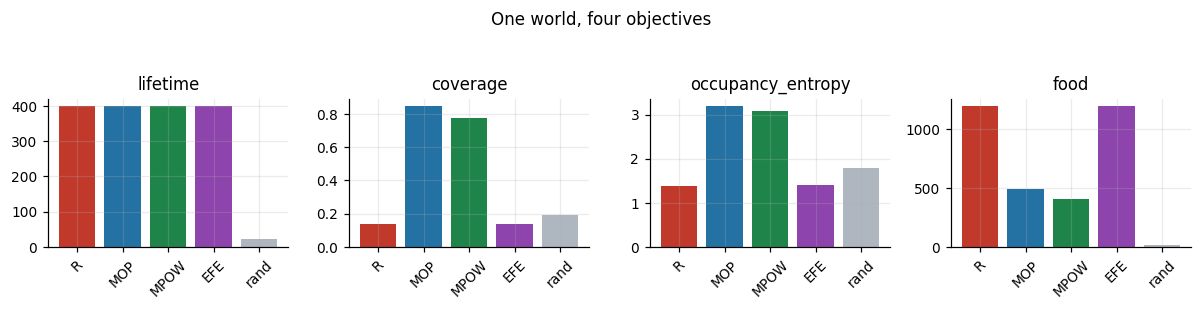

In [ ]:
#@title Behavioural comparison
def behaviour_stats(P, env, n_ep=60, n_steps=400, seed=0):
    rng = np.random.default_rng(seed)
    life, cov, occH, food = [], [], [], []
    for _ in range(n_ep):
        s0 = env.sid(env.cells[rng.integers(env.nC)], env.F)
        S, A = env.rollout(P, s0, n_steps, rng)
        life.append(len(S))
        cells = np.array([s // env.nU for s in S])
        u, c = np.unique(cells, return_counts=True)
        p = c / c.sum()
        cov.append(len(u) / env.nC)
        occH.append(-(p * np.log(p)).sum())
        food.append(sum(env.food_intake[S[t], A[t]] for t in range(len(A))))
    return dict(lifetime=np.mean(life), coverage=np.mean(cov),
                occupancy_entropy=np.mean(occH), food=np.mean(food))

rows = {k: behaviour_stats(P, env) for k, P in POLICIES.items()}
tab = pd.DataFrame(rows).T
display(tab.round(2))

fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))
for ax, col in zip(axes, tab.columns):
    ax.bar(tab.index, tab[col], color=[C[k] for k in tab.index])
    ax.set_title(col); ax.tick_params(axis="x", rotation=45)
fig.suptitle("One world, four objectives", y=1.06, fontsize=11)
plt.tight_layout(); plt.show()

**What to look at.** The random agent survives 23 steps, so mere survival is a non-trivial
achievement in this world. All four principled agents hit the 400-step cap, but they get there
in completely different ways:

| | lifetime | coverage | occupancy entropy | food |
|---|---|---|---|---|
| R | 401 | 0.14 | 1.39 | 1200 |
| MOP | 401 | **0.85** | **3.20** | 491 |
| MPOW | 401 | 0.78 | 3.08 | 410 |
| EFE | 401 | 0.14 | 1.40 | 1197 |
| random | 23 | 0.19 | 1.78 | 14 |

The R and EFE agents survive by camping on food: nearly three times the intake, but they visit
14% of the world. The MOP agent survives *just as well without ever being told that food is
good* — it keeps itself alive because dying collapses its future path space — and it covers 85%
of the world while doing so, six times the extrinsic agent's range. This reproduces the central
claim of *Complex behavior from intrinsic motivation to occupy future action-state path space*.

This is the first crack in the reward hypothesis, and so far only a rhetorical one: MOP
behaviour *looks* purposive and *is* adaptive, but nothing in the agent maximises a reward the
environment supplies. Part 3 turns this into a formal test.

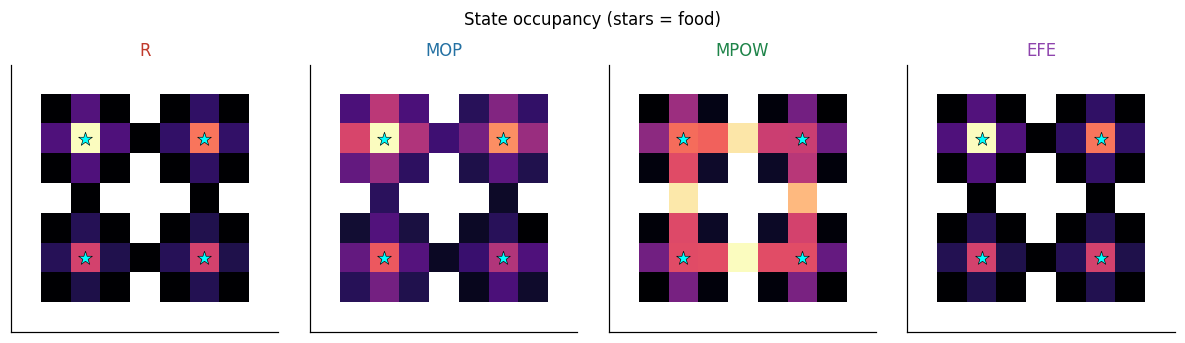

In [ ]:
#@title Where does each objective spend its time? (occupancy maps)
def occupancy_map(P, env, n_ep=40, n_steps=400, seed=1):
    rng = np.random.default_rng(seed)
    M = np.zeros((env.H, env.W))
    for _ in range(n_ep):
        s0 = env.sid(env.cells[rng.integers(env.nC)], env.F)
        S, _ = env.rollout(P, s0, n_steps, rng)
        for s in S:
            (i, j), _ = env.decode(s)
            M[i, j] += 1
    M[env.walls] = np.nan
    return M / np.nansum(M)

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, k in zip(axes, ["R", "MOP", "MPOW", "EFE"]):
    M = occupancy_map(POLICIES[k], env)
    ax.imshow(M, cmap="magma")
    fi, fj = np.where(env.food > 0)
    ax.scatter(fj, fi, marker="*", s=90, c="cyan", edgecolors="k", linewidths=.4)
    ax.set_title(k, color=C[k]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("State occupancy (stars = food)", y=1.02)
plt.tight_layout(); plt.show()

---
# Part 2 — What if *evolution* is the optimiser?

Part 1 handed each objective to an exact dynamic-programming solver. Real organisms do not get
that. They get a genome, a body, and a selection filter. So now we replace the solver with a
**Markov Brain** — the substrate from *From Function to Implementation* — and replace
optimisation with a genetic algorithm.

A Markov Brain is a set of probabilistic logic gates wired between binary nodes, partitioned
into sensors (written by the world), hidden nodes (the organism's own state) and motors (read
by the world). It is deliberately minimal: it is about as much "nervous system" as you can have
and still have one.

The experiment: **evolve four populations, each selected on a different one of the four
objectives, and then measure all of them on all criteria.**

In [ ]:
#@title Markov Brain substrate + genetic algorithm
"""
markov_brain.py -- Markov Brains (Hintze/Adami/Marstaller; the MABE substrate)
reimplemented in numpy so it runs in Colab without the C++ toolchain.

A Markov Brain is a set of probabilistic logic gates wired between binary
nodes.  Nodes are partitioned into SENSORS (overwritten by the world),
HIDDEN (the agent's own state -- its memory / interoception) and MOTORS
(read by the world).  Gates read node values at t and write node values at
t+1; multiple writes to a node are OR-ed.

Because the brain is a finite deterministic (or stochastic) automaton, we can
extract its transition probability matrix (TPM) exactly, which is what the
`autonomy` package of Albantakis (2021) and the degeneracy paper analyse.
"""
import numpy as np


class Gate:
    __slots__ = ("ins", "outs", "table", "_det", "_pow_in", "_outbits")

    def __init__(self, ins, outs, table):
        self.ins = np.asarray(ins, dtype=int)      # node indices read
        self.outs = np.asarray(outs, dtype=int)    # node indices written
        self.table = np.asarray(table, dtype=float)  # (2^k, 2^m) row-stochastic
        self.recompile()

    def recompile(self):
        k, m = len(self.ins), len(self.outs)
        self._pow_in = (1 << np.arange(k)[::-1])
        self._det = self.table.max(axis=1).min() >= 1.0
        rows = self.table.argmax(axis=1)
        self._outbits = ((rows[:, None] >> np.arange(m)[::-1]) & 1).astype(np.int8)

    def copy(self):
        return Gate(self.ins.copy(), self.outs.copy(), self.table.copy())


class MarkovBrain:
    def __init__(self, n_sensors, n_hidden, n_motors, gates=None):
        self.nS, self.nH, self.nM = n_sensors, n_hidden, n_motors
        self.n = n_sensors + n_hidden + n_motors
        self.sensor_ix = list(range(n_sensors))
        self.hidden_ix = list(range(n_sensors, n_sensors + n_hidden))
        self.motor_ix = list(range(n_sensors + n_hidden, self.n))
        self.gates = gates if gates is not None else []
        self.state = np.zeros(self.n, dtype=np.int8)

    # -- runtime --------------------------------------------------------
    def reset(self):
        self.state[:] = 0

    def step(self, sensor_values, rng):
        st = self.state
        st[self.sensor_ix] = sensor_values
        nxt = np.zeros(self.n, dtype=np.int8)
        for g in self.gates:
            idx = int(st[g.ins] @ g._pow_in)
            if g._det:
                bits = g._outbits[idx]
            else:
                out = rng.choice(g.table.shape[1], p=g.table[idx])
                m = len(g.outs)
                bits = np.array([(out >> b) & 1 for b in range(m)[::-1]], dtype=np.int8)
            np.bitwise_or.at(nxt, g.outs, bits)
        nxt[self.sensor_ix] = 0
        self.state = nxt
        return nxt[self.motor_ix]

    # -- exact automaton ------------------------------------------------
    def tpm(self):
        """Deterministic-approximation TPM over the 2^(nH+nM) non-sensor states
        crossed with all 2^nS sensor inputs is huge; we follow the MABE/autonomy
        convention and build the state-by-node TPM over ALL n nodes.
        Returns (2^n, n) array: P(node_i = 1 at t+1 | full state at t)."""
        n = self.n
        N = 1 << n
        out = np.zeros((N, n))
        bits = ((np.arange(N)[:, None] >> np.arange(n)[::-1]) & 1).astype(np.int8)
        for g in self.gates:
            k, m = len(g.ins), len(g.outs)
            idx = (bits[:, g.ins] * (1 << np.arange(k)[::-1])).sum(axis=1)
            probs = g.table[idx]                       # (N, 2^m)
            outvals = np.arange(1 << m)
            obits = ((outvals[:, None] >> np.arange(m)[::-1]) & 1).astype(float)
            p1 = probs @ obits                         # (N, m) marginal P(bit=1)
            for j, node in enumerate(g.outs):
                # OR-combination of independent writers
                out[:, node] = out[:, node] + p1[:, j] - out[:, node] * p1[:, j]
        return out

    def connectivity(self):
        cm = np.zeros((self.n, self.n), dtype=int)
        for g in self.gates:
            for i in g.ins:
                for o in g.outs:
                    cm[i, o] = 1
        return cm

    def copy(self):
        b = MarkovBrain(self.nS, self.nH, self.nM,
                        [g.copy() for g in self.gates])
        return b


# ---------------------------------------------------------------------
def random_gate(n_nodes, rng, max_in=3, max_out=2, readable=None, writable=None):
    readable = readable if readable is not None else list(range(n_nodes))
    writable = writable if writable is not None else list(range(n_nodes))
    k = rng.integers(1, max_in + 1)
    m = rng.integers(1, max_out + 1)
    ins = rng.choice(readable, size=k, replace=True)
    outs = rng.choice(writable, size=m, replace=False) if m <= len(writable) \
        else rng.choice(writable, size=m, replace=True)
    table = np.zeros((1 << k, 1 << m))
    for r in range(1 << k):
        table[r, rng.integers(1 << m)] = 1.0          # deterministic gates
    return Gate(ins, outs, table)


def random_brain(nS, nH, nM, n_gates, rng, **kw):
    """Follows the MABE architecture used in the degeneracy paper: gates read
    sensors and hidden units only, and write hidden and motor units only, so
    motors act on the world but never feed back into the brain."""
    n = nS + nH + nM
    readable = list(range(0, nS + nH))                # sensors + hidden
    writable = list(range(nS, n))                     # hidden + motors
    gates = [random_gate(n, rng, readable=readable, writable=writable, **kw)
             for _ in range(n_gates)]
    return MarkovBrain(nS, nH, nM, gates)


def mutate(brain, rng, p_table=0.05, p_wire=0.03,
           p_dup=0.05, p_del=0.05, max_gates=12):
    b = brain.copy()
    n = b.n
    readable = list(range(0, b.nS + b.nH))
    writable = list(range(b.nS, n))
    for g in b.gates:
        # rewire
        for i in range(len(g.ins)):
            if rng.random() < p_wire:
                g.ins[i] = readable[rng.integers(len(readable))]
        for i in range(len(g.outs)):
            if rng.random() < p_wire:
                g.outs[i] = writable[rng.integers(len(writable))]
        # flip table entries
        for r in range(g.table.shape[0]):
            if rng.random() < p_table:
                g.table[r] = 0.0
                g.table[r, rng.integers(g.table.shape[1])] = 1.0
        g.recompile()
    if rng.random() < p_dup and len(b.gates) < max_gates:
        b.gates.append(b.gates[rng.integers(len(b.gates))].copy())
    if rng.random() < p_del and len(b.gates) > 1:
        del b.gates[rng.integers(len(b.gates))]
    return b


# =====================================================================
# Embodiment: a Markov Brain driving an agent in LifeGrid
# =====================================================================
class GridBody:
    """Sensors: 4 wall-detectors + 1 food-here + k interoceptive energy bits.
    Motors: 2 bits -> one of 4 actions."""

    def __init__(self, env, n_energy_bits=2):
        self.env = env
        self.n_energy_bits = n_energy_bits
        self.n_sensors = 5 + n_energy_bits
        self.n_motors = 2

    def sensor_table(self):
        if not hasattr(self, "_stab"):
            self._stab = np.array([self.sense(s) for s in range(self.env.nS)],
                                  dtype=np.int8)
        return self._stab

    def sense(self, s):
        (i, j), u = self.env.decode(s)
        e = self.env
        v = []
        for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            ni, nj = i + di, j + dj
            blocked = (not (0 <= ni < e.H and 0 <= nj < e.W)) or e.walls[ni, nj]
            v.append(int(blocked))
        v.append(int(e.food[i, j] > 0))
        # interoception: energy level coarse-coded into n_energy_bits
        if self.n_energy_bits > 0:
            frac = u / e.F
            edges = np.linspace(0.0, 1.0, self.n_energy_bits + 2)[1:-1]
            v += [int(frac > t) for t in edges]
        return np.array(v[:self.n_sensors], dtype=np.int8)

    def act(self, motor_bits):
        return int(motor_bits[0] * 2 + motor_bits[1])


def run_episode(brain, body, s0, n_steps, rng):
    env = body.env
    stab = body.sensor_table()
    T = env.T
    nU = env.nU
    brain.reset()
    s = s0
    S = np.empty(n_steps + 1, dtype=np.int64); S[0] = s
    A = np.empty(n_steps, dtype=np.int64)
    t = 0
    for t in range(n_steps):
        if s % nU == 0:
            break
        mb = brain.step(stab[s], rng)
        a = int(mb[0]) * 2 + int(mb[1])
        s = T[s, a]
        A[t] = a
        S[t + 1] = s
    else:
        t = n_steps
    return S[:t + 1], A[:t]


# =====================================================================
# Fitness functions = four different "rewards" an evolutionary process
# could be maximising
# =====================================================================
def fitness_extrinsic(S, A, env, **kw):
    """Food eaten per episode (classic scalar reward)."""
    if len(A) == 0:
        return 0.0
    return float(sum(env.food_intake[S[t], A[t]] for t in range(len(A))))


def fitness_survival(S, A, env, **kw):
    return float(len(S))


def fitness_MOP(S, A, env, **kw):
    """Empirical occupancy of action-state path space: entropy of the realised
    (state, action) distribution, scaled by how long the agent stayed alive.
    Dying collapses future path space, so lifetime multiplies the entropy."""
    if len(A) < 2:
        return 0.0
    pairs = S[:-1] * env.nA + A
    _, c = np.unique(pairs, return_counts=True)
    p = c / c.sum()
    H = -(p * np.log(p)).sum()
    return float(H * len(A))


def fitness_MPOW(S, A, env, E=None, **kw):
    """Mean n-step empowerment of the states actually occupied."""
    if E is None or len(S) == 0:
        return 0.0
    return float(E[S].mean() * len(S))


def fitness_EFE(S, A, env, V_efe=None, **kw):
    if V_efe is None or len(S) == 0:
        return 0.0
    return float(V_efe[S].mean())


FITNESS = {
    "R":    fitness_extrinsic,
    "MOP":  fitness_MOP,
    "MPOW": fitness_MPOW,
    "EFE":  fitness_EFE,
    "surv": fitness_survival,
}


# =====================================================================
def evolve(body, fitness_name, n_gen=40, pop=40, n_hidden=4, n_gates=6,
           n_steps=120, n_episodes=3, seed=0, elite=2, aux=None,
           track=None):
    """Simple GA. Returns (best_brain, history)."""
    rng = np.random.default_rng(seed)
    env = body.env
    fn = FITNESS[fitness_name]
    aux = aux or {}
    population = [random_brain(body.n_sensors, n_hidden, body.n_motors,
                               n_gates, rng) for _ in range(pop)]
    starts = [env.sid(c, env.F) for c in env.cells]
    hist = []
    best_brain, best_fit = None, -np.inf
    for gen in range(n_gen):
        fits, extra = [], []
        for b in population:
            f, rec = 0.0, []
            for ep in range(n_episodes):
                s0 = starts[rng.integers(len(starts))]
                S, A = run_episode(b, body, s0, n_steps, rng)
                f += fn(S, A, env, **aux)
                rec.append((S, A))
            fits.append(f / n_episodes)
            extra.append(rec)
        fits = np.array(fits)
        order = np.argsort(-fits)
        if fits[order[0]] > best_fit:
            best_fit = fits[order[0]]
            best_brain = population[order[0]].copy()
        row = dict(gen=gen, best=float(fits.max()), mean=float(fits.mean()))
        if track is not None:
            row.update(track(population[order[0]], extra[order[0]], env))
        hist.append(row)
        # tournament selection
        newpop = [population[i].copy() for i in order[:elite]]
        while len(newpop) < pop:
            i, j = rng.integers(pop), rng.integers(pop)
            parent = population[i] if fits[i] >= fits[j] else population[j]
            newpop.append(mutate(parent, rng))
        population = newpop
    return best_brain, hist


In [ ]:
#@title Evolve four populations (~60 s)
body = GridBody(env, n_energy_bits=2)
print(f"body: {body.n_sensors} sensors (4 wall + 1 food + 2 interoceptive), "
      f"{body.n_motors} motors")

AUX = {"R": {}, "MOP": {}, "MPOW": {"E": E_emp}, "EFE": {"V_efe": V_EFE}}
GA = dict(n_gen=60, pop=50, n_hidden=4, n_gates=6, n_steps=150,
          n_episodes=3, seed=2)

brains, histories = {}, {}
for name in ["R", "MOP", "MPOW", "EFE"]:
    b, h = evolve(body, name, aux=AUX[name], **GA)
    brains[name], histories[name] = b, h
    print(f"  {name:5s} evolved: fitness {h[-1]['best']:8.2f}, {len(b.gates)} gates")

body: 7 sensors (4 wall + 1 food + 2 interoceptive), 2 motors


  R     evolved: fitness   448.00, 7 gates


  MOP   evolved: fitness   433.83, 7 gates


  MPOW  evolved: fitness   450.81, 9 gates


  EFE   evolved: fitness   480.00, 6 gates


,lifetime,food,path_entropy,empowerment,coverage
selected for,,,,,
R,93.64,250.32,2.01,2.58,0.07
MOP,301.00,295.20,2.67,2.84,0.24
MPOW,208.84,235.68,1.97,2.81,0.08
EFE,174.32,250.08,2.29,2.72,0.11


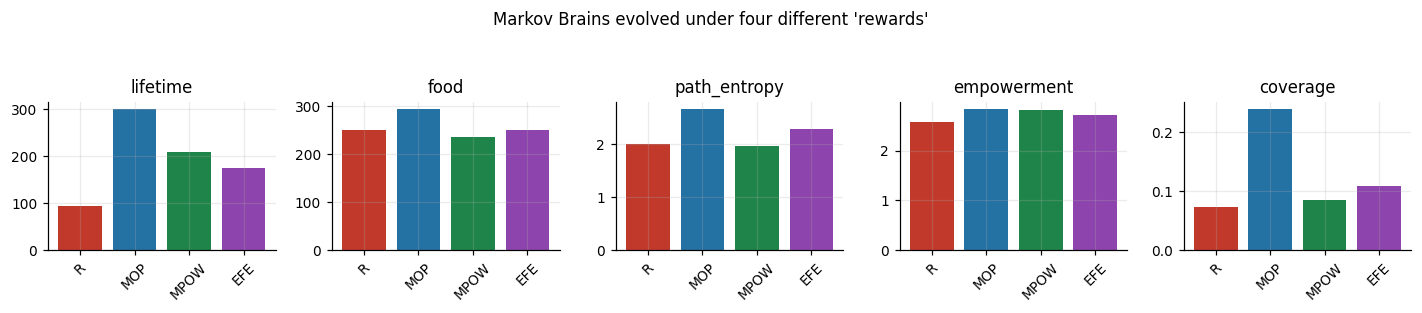

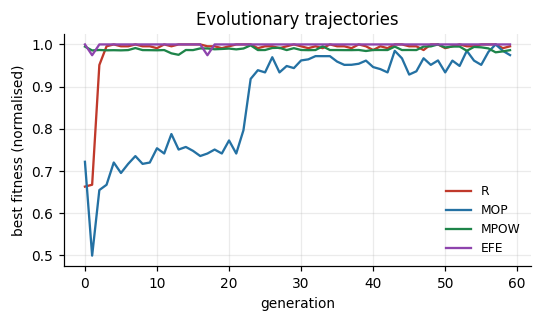

In [ ]:
#@title Evaluate every evolved brain on every criterion
def eval_brain(brain, body, n_ep=25, n_steps=300, seed=11):
    env = body.env
    rng = np.random.default_rng(seed)
    life, food, pathH, emp, cov = [], [], [], [], []
    for k in range(n_ep):
        s0 = env.sid(env.cells[k % env.nC], env.F)
        S, A = run_episode(brain, body, s0, n_steps, rng)
        life.append(len(S))
        food.append(fitness_extrinsic(S, A, env))
        pathH.append(fitness_MOP(S, A, env) / max(len(A), 1))
        emp.append(E_emp[S].mean() if len(S) else 0)
        cov.append(len(np.unique(S // env.nU)) / env.nC)
    return dict(lifetime=np.mean(life), food=np.mean(food),
                path_entropy=np.mean(pathH), empowerment=np.mean(emp),
                coverage=np.mean(cov))

ev = pd.DataFrame({k: eval_brain(b, body) for k, b in brains.items()}).T
ev.index.name = "selected for"
display(ev.round(2))

fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
for ax, col in zip(axes, ev.columns):
    ax.bar(ev.index, ev[col], color=[C[k] for k in ev.index])
    ax.set_title(col); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Markov Brains evolved under four different 'rewards'", y=1.07)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
for k, h in histories.items():
    v = np.array([r["best"] for r in h])
    ax.plot(v / max(v.max(), 1e-9), color=C[k], label=k)
ax.set_xlabel("generation"); ax.set_ylabel("best fitness (normalised)")
ax.legend(frameon=False, fontsize=8); ax.set_title("Evolutionary trajectories")
plt.tight_layout(); plt.show()

**What to look at.** Compare the `lifetime` column against which objective each population was
*selected on*:

| selected on | lifetime | food | path entropy | empowerment | coverage |
|---|---|---|---|---|---|
| R | 94 | 250 | 2.01 | 2.58 | 0.07 |
| MOP | **301** | 295 | 2.67 | 2.84 | 0.24 |
| MPOW | 209 | 236 | 1.97 | 2.81 | 0.08 |
| EFE | 174 | 250 | 2.29 | 2.72 | 0.11 |

The population selected on the intrinsic occupancy objective outlives the population selected
directly on food by more than three to one — and it collects *more food* while doing it, even
though nobody told it food was good. Selection on empowerment also beats selection on food.

Be careful about what this shows. With a fixed, small GA budget, selection on a dense intrinsic
signal is an easier optimisation problem than selection on a sparse extrinsic one. That is itself
an evolutionary argument — intrinsic objectives may be *evolvable* where extrinsic ones are not —
but it is an argument about search, not about what is ultimately being maximised. Re-run with
`n_gen=200` to see how much of the gap is budget.

> **Things to try.** Set `n_energy_bits=0` in `GridBody` to blind the organism to its own energy
> and re-run. That single change drives Parts 4 and 10.

---
# Part 3 — Testing the reward hypothesis

> *"All of what we mean by goals and purposes can be well thought of as maximization of the
> expected value of the cumulative sum of a received scalar signal."*
> — the reward hypothesis (Sutton; formalised by Bowling, Martin, Abel & Dabney, ICML 2023)

You asked whether this can be tested rather than argued about. It can, and here is how, in
three steps.

### Step 1: the hypothesis is trivially true about *behaviours*

For **any** deterministic policy π there is a Markov reward making π optimal: put reward 1 on
π's own action in each state. So "this behaviour can be seen as reward maximisation" is a claim
with no content. Worse, `R ≡ 0` makes *every* policy optimal, which is the unidentifiability at
the heart of inverse RL (Ng & Russell, 2000).

### Step 2: the hypothesis is non-trivially false about *tasks*

Following Abel et al. (NeurIPS 2021), a **task** is not one policy but the *set* of acceptable
ones (a SOAP: set of acceptable policies). And here there is a hard structural constraint:

> In a Markov-reward MDP the optimal deterministic policies are exactly the **state-wise
> selections** from the argmax sets of Q\*. So the optimal set is always a **Cartesian
> product** of per-state action sets.

Therefore: **if the set of acceptable behaviours is not a Cartesian product, no Markov reward
function can express that task** — not a badly chosen one, *none*. This is a decidable property
that needs no transition model at all. That is our test.

### Step 3: which side of the line a task falls on depends on the organism

And that, in Part 4, is where evolution comes in.

In [ ]:
#@title Reward-hypothesis test suite
"""
reward_tests.py -- operational tests of the reward hypothesis.

The reward hypothesis (Sutton; formalised by Bowling, Martin, Abel & Dabney,
ICML 2023) says goals and purposes can be captured as maximisation of expected
cumulative scalar reward.  Abel et al. (NeurIPS 2021) proved that some tasks
are NOT expressible by any Markov reward function.

Here we turn that into runnable experiments:

  TEST A  expressibility : does there EXIST a Markov reward R on this state
                           space making exactly this behaviour optimal?
                           -> linear feasibility programme.
  TEST B  degeneracy     : if it exists, HOW MANY such R are there?
                           -> dimension / volume of the feasible cone.
  TEST C  state-space    : does expressibility depend on what the agent can
                           represent (interoception, memory)?
                           -> rerun TEST A on an enlarged state space.
"""
import numpy as np
from scipy.optimize import linprog


class SimpleMDP:
    """Finite, deterministic MDP. T[s,a] -> s'."""
    def __init__(self, T, gamma=0.95, labels=None, absorbing=None):
        self.T = np.asarray(T, dtype=np.int64)
        self.nS, self.nA = self.T.shape
        self.gamma = gamma
        self.labels = labels or [str(i) for i in range(self.nS)]
        self.absorbing = np.zeros(self.nS, bool) if absorbing is None \
            else np.asarray(absorbing, bool)


# ---------------------------------------------------------------------
# TEST A -- Markov-reward expressibility
# ---------------------------------------------------------------------
def expressibility_lp(mdp, support, rmax=1.0, return_reward=False):
    """
    support : (nS, nA) boolean. support[s,a] = True means "action a is
              acceptable in state s".  The behaviour we are trying to
              rationalise is: in every state, exactly the supported actions
              are optimal.

    Returns (margin, R) where margin = max eps s.t. a Markov reward R with
    |R|<=rmax makes every supported action optimal and every unsupported
    action at least eps worse.  margin > 0  =>  expressible (strictly).
    margin <= 0 =>  NOT expressible on this state space.

    Construction.  Let pi be uniform over the supported actions.  Then
        V = (I - gamma P_pi)^-1 R_pi ,     R_pi = Pi R
    is linear in R, so every Bellman (in)equality below is linear in R.
    """
    nS, nA, gam, T = mdp.nS, mdp.nA, mdp.gamma, mdp.T
    sup = np.asarray(support, bool)
    if not sup.any(axis=1).all():
        raise ValueError("every state needs at least one supported action")

    # pi uniform on support
    pi = sup.astype(float)
    pi /= pi.sum(axis=1, keepdims=True)

    # Pi : (nS, nS*nA) so that R_pi = Pi @ r
    Pi = np.zeros((nS, nS * nA))
    for s in range(nS):
        for a in range(nA):
            Pi[s, s * nA + a] = pi[s, a]

    # P_pi
    Ppi = np.zeros((nS, nS))
    for s in range(nS):
        for a in range(nA):
            if pi[s, a] > 0:
                Ppi[s, T[s, a]] += pi[s, a]
    for s in np.where(mdp.absorbing)[0]:
        Ppi[s, :] = 0.0

    M = np.linalg.inv(np.eye(nS) - gam * Ppi)      # V = M @ Pi @ r
    VofR = M @ Pi                                   # (nS, nS*nA)

    # Q(s,a) = r(s,a) + gamma * V(T[s,a])
    rows_eq, rows_ub = [], []
    for s in range(nS):
        if mdp.absorbing[s]:
            continue
        for a in range(nA):
            qa = np.zeros(nS * nA)
            qa[s * nA + a] = 1.0
            qa += gam * VofR[T[s, a]]
            row = qa - VofR[s]                      # Q(s,a) - V(s)
            if sup[s, a]:
                rows_eq.append(row)                 # == 0  (tied optimal)
            else:
                rows_ub.append(row)                 # <= -eps

    nvar = nS * nA + 1                              # r, eps
    c = np.zeros(nvar); c[-1] = -1.0                # maximise eps

    A_eq = np.zeros((len(rows_eq), nvar))
    if rows_eq:
        A_eq[:, :-1] = np.array(rows_eq)
    b_eq = np.zeros(len(rows_eq))

    A_ub = np.zeros((len(rows_ub), nvar))
    if rows_ub:
        A_ub[:, :-1] = np.array(rows_ub)
        A_ub[:, -1] = 1.0                           # Q - V + eps <= 0
    b_ub = np.zeros(len(rows_ub))

    bounds = [(-rmax, rmax)] * (nS * nA) + [(None, 1.0)]
    res = linprog(c, A_ub=A_ub if len(rows_ub) else None,
                  b_ub=b_ub if len(rows_ub) else None,
                  A_eq=A_eq if len(rows_eq) else None,
                  b_eq=b_eq if len(rows_eq) else None,
                  bounds=bounds, method="highs")
    if not res.success:
        return (-np.inf, None) if return_reward else -np.inf
    margin = res.x[-1]
    R = res.x[:-1].reshape(nS, nA)
    return (margin, R) if return_reward else margin


def is_expressible(mdp, support, eps=1e-6):
    return expressibility_lp(mdp, support) > eps


# ---------------------------------------------------------------------
# TEST B -- degeneracy of the rationalising reward set
# ---------------------------------------------------------------------
def reward_degeneracy(mdp, support, n_samples=200, seed=0, rmax=1.0):
    """Sample many rationalising rewards by randomising the LP objective.
    Returns (rank, effective_dim, rewards).
      rank           : dimension of the affine hull of the feasible set
      effective_dim  : participation ratio of the PCA spectrum
    Large values mean: the behaviour massively underdetermines the reward
    (the inverse-RL degeneracy of Ng & Russell, 2000)."""
    rng = np.random.default_rng(seed)
    nS, nA, gam, T = mdp.nS, mdp.nA, mdp.gamma, mdp.T
    sup = np.asarray(support, bool)
    pi = sup.astype(float); pi /= pi.sum(axis=1, keepdims=True)
    Pi = np.zeros((nS, nS * nA))
    for s in range(nS):
        for a in range(nA):
            Pi[s, s * nA + a] = pi[s, a]
    Ppi = np.zeros((nS, nS))
    for s in range(nS):
        for a in range(nA):
            if pi[s, a] > 0:
                Ppi[s, T[s, a]] += pi[s, a]
    for s in np.where(mdp.absorbing)[0]:
        Ppi[s, :] = 0.0
    VofR = np.linalg.inv(np.eye(nS) - gam * Ppi) @ Pi

    rows_eq, rows_ub = [], []
    for s in range(nS):
        if mdp.absorbing[s]:
            continue
        for a in range(nA):
            qa = np.zeros(nS * nA); qa[s * nA + a] = 1.0
            qa += gam * VofR[T[s, a]]
            (rows_eq if sup[s, a] else rows_ub).append(qa - VofR[s])
    A_eq = np.array(rows_eq) if rows_eq else None
    b_eq = np.zeros(len(rows_eq)) if rows_eq else None
    A_ub = np.array(rows_ub) if rows_ub else None
    b_ub = -1e-4 * np.ones(len(rows_ub)) if rows_ub else None
    bounds = [(-rmax, rmax)] * (nS * nA)

    out = []
    for _ in range(n_samples):
        c = rng.normal(size=nS * nA)
        r = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                    bounds=bounds, method="highs")
        if r.success:
            out.append(r.x)
    if not out:
        return 0, 0.0, np.zeros((0, nS * nA))
    Rs = np.array(out)
    X = Rs - Rs.mean(axis=0)
    sv = np.linalg.svd(X, compute_uv=False)
    rank = int((sv > 1e-7 * max(1.0, sv.max())).sum())
    lam = sv ** 2
    eff = float(lam.sum() ** 2 / (lam ** 2).sum()) if lam.sum() > 0 else 0.0
    return rank, eff, Rs


# ---------------------------------------------------------------------
# behaviour -> support helpers
# ---------------------------------------------------------------------
def support_from_policy(P, thresh=0.25):
    """Turn a stochastic policy into a behavioural signature."""
    sup = P >= thresh * P.max(axis=1, keepdims=True)
    sup[~sup.any(axis=1)] = True
    return sup


def support_from_trajectories(states, actions, nS, nA, min_frac=0.2):
    """Empirical behavioural signature from observed behaviour only."""
    cnt = np.zeros((nS, nA))
    for s, a in zip(states, actions):
        cnt[s, a] += 1
    seen = cnt.sum(axis=1) > 0
    sup = np.zeros((nS, nA), bool)
    with np.errstate(invalid='ignore'):
        frac = cnt / np.where(cnt.sum(axis=1, keepdims=True) > 0,
                              cnt.sum(axis=1, keepdims=True), 1)
    sup[seen] = frac[seen] >= min_frac
    sup[~seen] = True                     # unconstrained where unobserved
    sup[~sup.any(axis=1)] = True
    return sup, seen


# ---------------------------------------------------------------------
# TEST C -- state-space augmentation (memory / interoception)
# ---------------------------------------------------------------------
def augment_with_memory(mdp, n_mem, mem_update):
    """Product MDP with an n_mem-valued internal variable.
    mem_update(s, a, s_next, m) -> m_next   (the agent's own bookkeeping)."""
    nS, nA = mdp.nS, mdp.nA
    NS = nS * n_mem
    T = np.zeros((NS, nA), dtype=np.int64)
    absorb = np.zeros(NS, bool)
    for s in range(nS):
        for m in range(n_mem):
            i = s * n_mem + m
            absorb[i] = mdp.absorbing[s]
            for a in range(nA):
                sn = mdp.T[s, a]
                mn = mem_update(s, a, sn, m)
                T[i, a] = sn * n_mem + mn
    labels = [f"{mdp.labels[s]}|m{m}" for s in range(nS) for m in range(n_mem)]
    return SimpleMDP(T, gamma=mdp.gamma, labels=labels, absorbing=absorb)


# ---------------------------------------------------------------------
# Canonical counter-example: alternation / patrolling
# ---------------------------------------------------------------------
def patrol_world(n=6):
    """A ring of n cells, food at 0 and n//2.  Actions: 0 = clockwise,
    1 = anticlockwise, 2 = stay."""
    T = np.zeros((n, 3), dtype=np.int64)
    for s in range(n):
        T[s, 0] = (s + 1) % n
        T[s, 1] = (s - 1) % n
        T[s, 2] = s
    return SimpleMDP(T, gamma=0.9, labels=[f"c{i}" for i in range(n)])


# ---------------------------------------------------------------------
# TEST A' -- SOAP tasks (Abel et al., NeurIPS 2021)
# ---------------------------------------------------------------------
# A *task* is not a single policy but a SET of acceptable policies (SOAP).
# A single deterministic policy is always trivially Markov-reward expressible
# (put reward 1 on its own action), so the interesting question is whether a
# SET can be the exact argmax set of some Markov reward.
#
# Structural fact: in a Markov-reward MDP the optimal deterministic policies
# are exactly the state-wise selections from the argmax sets of Q*.  Hence the
# optimal set is always a CARTESIAN PRODUCT of per-state action sets.  A task
# whose acceptable set is not such a product is therefore NOT expressible by
# any Markov reward, no matter how it is designed.

def product_closure(policies, nA):
    """policies: (K, nS) int array of deterministic policies."""
    policies = np.atleast_2d(np.asarray(policies, dtype=int))
    nS = policies.shape[1]
    A_s = [sorted(set(policies[:, s].tolist())) for s in range(nS)]
    size = int(np.prod([len(a) for a in A_s]))
    sup = np.zeros((nS, nA), bool)
    for s in range(nS):
        sup[s, A_s[s]] = True
    return A_s, size, sup


def soap_expressible(mdp, policies, verbose=False):
    """Can a Markov reward make EXACTLY this set of policies optimal?"""
    policies = np.atleast_2d(np.asarray(policies, dtype=int))
    K = len(policies)
    A_s, closure_size, sup = product_closure(policies, mdp.nA)
    is_product = (closure_size == K)
    margin = expressibility_lp(mdp, sup) if is_product else -np.inf
    res = dict(n_acceptable=K, closure_size=closure_size,
               is_product_set=is_product,
               lp_margin=margin,
               expressible=bool(is_product and margin > 1e-6),
               per_state_actions=A_s)
    if verbose:
        print(f"  |acceptable set|      = {K}")
        print(f"  |product closure|     = {closure_size}")
        print(f"  product set?          = {is_product}")
        print(f"  LP separation margin  = {margin if np.isfinite(margin) else 'n/a'}")
        print(f"  MARKOV-REWARD EXPRESSIBLE: {res['expressible']}")
    return res


# ---------------------------------------------------------------------
# TEST C' -- is the behaviour Markov in the agent's own state space?
# ---------------------------------------------------------------------
def policy_consistency(states, actions, nS, nA):
    """Conditional entropy H(A|S) of observed behaviour, in bits.
    0  => behaviour is a deterministic function of the state (Markov).
    >0 => the same state licenses different actions: either the agent is
          stochastic, or its behaviour depends on something not in S."""
    cnt = np.zeros((nS, nA))
    for s, a in zip(states, actions):
        cnt[s, a] += 1
    tot = cnt.sum()
    if tot == 0:
        return 0.0
    ps = cnt.sum(axis=1) / tot
    H = 0.0
    for s in range(nS):
        n = cnt[s].sum()
        if n == 0:
            continue
        p = cnt[s] / n
        p = p[p > 0]
        H += ps[s] * (-(p * np.log2(p)).sum())
    return H


def memory_gain(states, actions, nS, nA, n_mem=2, mem_fn=None):
    """How much of the apparent non-Markov-ness is removed by one internal
    variable?  Returns H(A|S), H(A|S,M) and the reduction."""
    if mem_fn is None:                       # default: previous action
        mem = np.zeros(len(states), dtype=int)
        for t in range(1, len(states)):
            mem[t] = actions[t - 1] % n_mem
    else:
        mem = np.asarray(mem_fn(states, actions), dtype=int)
    H_s = policy_consistency(states, actions, nS, nA)
    joint = np.asarray(states) * n_mem + mem
    H_sm = policy_consistency(joint, actions, nS * n_mem, nA)
    return dict(H_A_given_S=H_s, H_A_given_SM=H_sm, reduction=H_s - H_sm)


In [ ]:
#@title TEST 1 — the vacuity result (why "can be seen as reward maximisation" says nothing)
m = patrol_world(6)

sup_cw = np.zeros((6, 3), bool); sup_cw[:, 0] = True
print("Task: 'always go clockwise' (one behaviour)")
_ = soap_expressible(m, [[0] * 6], verbose=True)

rank, eff, Rs = reward_degeneracy(m, sup_cw, n_samples=150)
print(f"\n  ...and how many reward functions produce it?")
print(f"  dimension of the rationalising reward set : {rank} / {m.nS * m.nA}")
print(f"  effective dimension (participation ratio) : {eff:.1f}")
print("  -> the behaviour pins down almost nothing about the reward.")

Task: 'always go clockwise' (one behaviour)
  |acceptable set|      = 1
  |product closure|     = 1
  product set?          = True
  LP separation margin  = 1.0
  MARKOV-REWARD EXPRESSIBLE: True

  ...and how many reward functions produce it?
  dimension of the rationalising reward set : 18 / 18
  effective dimension (participation ratio) : 13.9
  -> the behaviour pins down almost nothing about the reward.


In [ ]:
#@title TEST 2 — a task that NO Markov reward can express
print("Task: 'circulate consistently — either always clockwise or always")
print("       anticlockwise — but never dither'.")
print("Acceptable set = {all-clockwise, all-anticlockwise}\n")
res = soap_expressible(m, [[0] * 6, [1] * 6], verbose=True)
print()
print("Why: a Markov reward that makes both acceptable policies optimal must make")
print(f"every state-wise mixture optimal too — all {res['closure_size']} of them, including")
print("'clockwise at c0, anticlockwise at c1, ...', which is exactly the dithering")
print("the task forbids. The reward hypothesis fails here, and not by accident.")

Task: 'circulate consistently — either always clockwise or always
       anticlockwise — but never dither'.
Acceptable set = {all-clockwise, all-anticlockwise}

  |acceptable set|      = 2
  |product closure|     = 64
  product set?          = False
  LP separation margin  = n/a
  MARKOV-REWARD EXPRESSIBLE: False

Why: a Markov reward that makes both acceptable policies optimal must make
every state-wise mixture optimal too — all 64 of them, including
'clockwise at c0, anticlockwise at c1, ...', which is exactly the dithering
the task forbids. The reward hypothesis fails here, and not by accident.


n_states,4,6,8
n_acceptable,,,
1,1.000,1.000,1.0
2,0.092,0.017,0.0
3,0.000,0.000,0.0
5,0.000,0.000,0.0
8,0.000,0.000,0.0


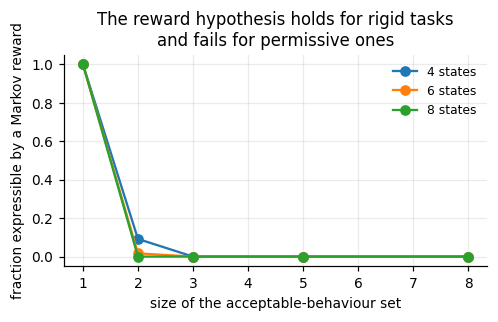

In [ ]:
#@title TEST 3 — where is the boundary? A systematic sweep
def random_soap(nS, nA, k, rng):
    return rng.integers(0, nA, size=(k, nS))

rng = np.random.default_rng(0)
rows = []
for nS in [4, 6, 8]:
    for k in [1, 2, 3, 5, 8]:
        ok = 0
        for _ in range(120):
            pol = np.unique(random_soap(nS, 3, k, rng), axis=0)
            _, closure, _ = product_closure(pol, 3)
            ok += (closure == len(pol))
        rows.append(dict(n_states=nS, n_acceptable=k, frac_expressible=ok / 120))
sweep = pd.DataFrame(rows).pivot(index="n_acceptable", columns="n_states",
                                 values="frac_expressible")
display(sweep.round(3))

fig, ax = plt.subplots(figsize=(4.6, 3))
for nS in sweep.columns:
    ax.plot(sweep.index, sweep[nS], "o-", label=f"{nS} states")
ax.set_xlabel("size of the acceptable-behaviour set")
ax.set_ylabel("fraction expressible by a Markov reward")
ax.legend(frameon=False, fontsize=8)
ax.set_title("The reward hypothesis holds for rigid tasks\nand fails for permissive ones")
plt.tight_layout(); plt.show()

**The shape of the result.** The numbers from the sweep:

| acceptable behaviours | 4 states | 6 states | 8 states |
|---|---|---|---|
| 1 | 1.000 | 1.000 | 1.000 |
| 2 | 0.092 | 0.017 | 0.000 |
| 3 | 0.000 | 0.000 | 0.000 |
| 5 | 0.000 | 0.000 | 0.000 |
| 8 | 0.000 | 0.000 | 0.000 |

A task with exactly one acceptable behaviour is always expressible. Allow a *second* acceptable
behaviour and expressibility falls to 9% at four states, 1.7% at six, and zero at eight. Allow a
third and it is zero everywhere we looked. Since essentially every biological task tolerates
alternatives — organisms are degenerate and the world is variable — this is not an exotic corner.

Note also the degeneracy result from TEST 1: the "always go clockwise" behaviour is rationalised
by an 18-dimensional set of reward functions, with an effective dimension of 13.9. The behaviour
pins down essentially nothing about the reward.

Together these give a clean statement of where the reward hypothesis stands:

- **As a modelling convenience** it is unfalsifiable, because of the vacuity result.
- **As a claim about tasks** it is straightforwardly false for a large and biologically natural
  class of them.
- **As a claim about a *specific* organism** it becomes testable only once you say which state
  space the reward is defined over — which is Dogma 1 of *Three Dogmas of Reinforcement
  Learning*. Part 4 attacks exactly that.

---
# Part 4 — Interoception: where value comes from

*Life-inspired interoceptive artificial intelligence* and the homeostatic-RL literature make a
claim that cuts against Dogma 1: for an organism, the same external outcome is rewarding,
neutral, or aversive **depending on the internal state**. Cabanac called this alliesthesia in
1971. A sugar solution is delicious when you are depleted and nauseating when you are loaded.

That has a sharp consequence for the reward hypothesis. If reward is a function of
`(external state, internal state)` and not of external state alone, then a reward function
defined over the *environment* cannot be the thing the organism is maximising. So the natural
question is: **what does adding interoception do to the expressibility of an organism's task?**

We answer it exhaustively on a world small enough to enumerate *every* memoryless policy.

In [ ]:
#@title Homeostasis, interoception and scale-dependent agency
"""
homeostasis.py -- interoception, homeostatic reward, and the central test:

    Does the SPACE the organism can represent determine whether its
    behaviour is expressible as maximisation of a scalar reward?

Key tool: a task defined as a SET of acceptable behaviours can only be the
optimal set of some Markov reward if that set is a CARTESIAN PRODUCT of
per-state action sets (see reward_tests.soap_expressible).  That criterion
needs no transition model, so we can apply it directly to any observation
space -- including ones in which the world is not even Markov.
"""
import itertools
import numpy as np


# ---------------------------------------------------------------------
# A world small enough to enumerate every memoryless policy
# ---------------------------------------------------------------------
class Corridor:
    """n cells in a line.  Food (energy +gain) at cell 0.  Energy u falls by 1
    each step; u = 0 is death.  Actions: 0 = left, 1 = right."""

    def __init__(self, n=5, F=5, gain=5):
        self.n, self.F, self.gain = n, F, gain

    def step(self, cell, u, a):
        nc = cell - 1 if a == 0 else cell + 1
        nc = min(max(nc, 0), self.n - 1)
        gain = self.gain if nc == 0 else 0
        nu = min(self.F, u - 1 + gain)
        return nc, max(0, nu)

    # --- observation spaces the organism might have -------------------
    def obs_cell(self, cell, u):
        return cell

    def obs_cell_energy(self, cell, u, nbits=1):
        """cell plus a coarse interoceptive signal (is energy low?)"""
        low = int(u <= self.F // 2) if nbits == 1 else int(u * nbits // (self.F + 1))
        return cell * (2 if nbits == 1 else nbits) + low

    def n_obs(self, kind, nbits=1):
        return self.n if kind == "cell" else self.n * (2 if nbits == 1 else nbits)


def survives(world, policy, obs_fn, n_obs, horizon=200, start_cell=None,
             start_u=None):
    """Run a memoryless observation->action policy; True if still alive."""
    cell = world.n - 1 if start_cell is None else start_cell
    u = world.F if start_u is None else start_u
    seen = set()
    for t in range(horizon):
        if u == 0:
            return False
        o = obs_fn(cell, u)
        a = policy[o]
        cell, u = world.step(cell, u, a)
        key = (cell, u)
        if key in seen:                       # entered a safe limit cycle
            return True
        seen.add(key)
    return u > 0


def enumerate_acceptable(world, obs_kind="cell", nbits=1, horizon=200,
                         starts=None):
    """All memoryless policies (over the given observation space) that keep
    the organism alive from every start.  Returns (policies, n_obs)."""
    if obs_kind == "cell":
        obs_fn = world.obs_cell
        n_obs = world.n
    else:
        obs_fn = lambda c, u: world.obs_cell_energy(c, u, nbits)
        n_obs = world.n * (2 if nbits == 1 else nbits)
    if starts is None:
        starts = [(c, world.F) for c in range(world.n)]
    good = []
    for pol in itertools.product(range(2), repeat=n_obs):
        pol = np.array(pol)
        if all(survives(world, pol, obs_fn, n_obs, horizon, c, u)
               for c, u in starts):
            good.append(pol)
    return (np.array(good) if good else np.zeros((0, n_obs), int)), n_obs


def product_set_report(policies, nA=2):
    """Is this set of acceptable policies a Cartesian product?  If not, NO
    Markov reward over this observation space can express the task."""
    policies = np.atleast_2d(policies)
    if len(policies) == 0:
        return dict(n_acceptable=0, closure=0, is_product=False,
                    expressible=False, excess=np.inf)
    n_obs = policies.shape[1]
    A_o = [sorted(set(policies[:, o].tolist())) for o in range(n_obs)]
    closure = int(np.prod([len(a) for a in A_o]))
    return dict(n_acceptable=len(policies), closure=closure,
                is_product=(closure == len(policies)),
                expressible=(closure == len(policies)),
                excess=closure / len(policies),
                per_obs_actions=A_o)


# ---------------------------------------------------------------------
# Homeostatic reward (Keramati & Gutkin, 2014)
# ---------------------------------------------------------------------
def drive(H, H_star, m=3.0, n=2.0):
    """D(H) = (sum_i |H*_i - H_i|^n)^(1/m)  -- distance from the setpoint."""
    H = np.atleast_1d(np.asarray(H, float))
    H_star = np.atleast_1d(np.asarray(H_star, float))
    return float((np.abs(H_star - H) ** n).sum() ** (1.0 / m))


def homeostatic_reward(H, dH, H_star, **kw):
    """Reward = reduction in drive.  The SAME external outcome is rewarding,
    neutral or aversive depending on the internal state (alliesthesia,
    Cabanac 1971)."""
    return drive(H, H_star, **kw) - drive(np.asarray(H) + np.asarray(dH),
                                          H_star, **kw)


def alliesthesia_curve(H_star=10.0, intake=3.0, H_range=None, **kw):
    """Reward of a fixed external outcome as a function of internal state."""
    H_range = np.linspace(0, 2 * H_star, 60) if H_range is None else H_range
    return H_range, np.array([homeostatic_reward([h], [intake], [H_star], **kw)
                              for h in H_range])


# ---------------------------------------------------------------------
# Scale-dependent agency: a collective of simple homeostatic cells
# ---------------------------------------------------------------------
class CellCollective:
    """N cells on a ring.  Each cell has a scalar state x_i and can only do
    three things: raise x, lower x, or do nothing.  Each cell locally tries to
    match the mean of its neighbours (a purely local homeostatic rule).
    Globally the tissue converges on a target PATTERN that no cell represents.

    This is the Levin-style setup: the goal exists at the collective scale
    only, and the competence at the collective scale is measurable even though
    every part is trivially simple."""

    def __init__(self, N=12, target=None, noise=0.0, seed=0):
        self.N = N
        self.rng = np.random.default_rng(seed)
        self.target = np.asarray(target, float) if target is not None else \
            np.sin(np.linspace(0, 2 * np.pi, N, endpoint=False))
        self.noise = noise
        self.reset()

    def reset(self, x=None):
        self.x = self.rng.normal(0, 0.3, self.N) if x is None else np.array(x, float)
        return self.x.copy()

    def local_rule(self, gain=0.35, target_gain=0.25):
        """Each cell: move toward the neighbourhood mean AND toward its own
        positional-information setpoint (a morphogen gradient it can read)."""
        nb = 0.5 * (np.roll(self.x, 1) + np.roll(self.x, -1))
        return gain * (nb - self.x) + target_gain * (self.target - self.x)

    def step(self, perturb=None):
        dx = self.local_rule()
        if perturb is not None:
            dx = dx + perturb
        self.x = self.x + dx + self.rng.normal(0, self.noise, self.N)
        return self.x.copy()

    def error(self):
        return float(np.mean((self.x - self.target) ** 2))

    def run(self, T=60, perturb_at=None, perturb_fn=None):
        traj, errs = [self.x.copy()], [self.error()]
        for t in range(T):
            if perturb_at is not None and t == perturb_at and perturb_fn:
                self.x = perturb_fn(self.x)
            self.step()
            traj.append(self.x.copy())
            errs.append(self.error())
        return np.array(traj), np.array(errs)


def goal_directedness(collective, T=60, n_perturb=12, severity=1.5, seed=0):
    """Operational test of goal-directedness (Rosenblueth/Sommerhoff style):
    perturb the system away from its end state and measure how reliably it
    returns.  Returns the mean fraction of the perturbation that is undone."""
    rng = np.random.default_rng(seed)
    collective.reset()
    collective.run(T)
    settled = collective.x.copy()
    scores = []
    for _ in range(n_perturb):
        p = rng.normal(0, severity, collective.N)
        collective.reset(settled + p)
        d0 = np.linalg.norm(collective.x - settled)
        collective.run(T)
        d1 = np.linalg.norm(collective.x - settled)
        scores.append(1.0 - d1 / max(d0, 1e-9))
    return float(np.mean(scores)), settled


def scale_agency(collective, T=40, seed=0):
    """Compare 'competence' at the cell scale and the tissue scale.
    Cell scale : how well does a single cell restore ITS OWN value when only
                 that cell is perturbed and neighbours are frozen?
    Tissue scale: how well does the whole sheet restore the pattern?"""
    rng = np.random.default_rng(seed)
    collective.reset(); collective.run(T)
    settled = collective.x.copy()
    N = collective.N
    cell_scores, tissue_scores = [], []
    for trial in range(10):
        p = rng.normal(0, 1.5, N)              # the SAME perturbation for both
        # --- cell scale: only cell i is allowed to act; the rest stay wrong
        for i in range(N):
            x = settled + p
            d0 = abs(x[i] - settled[i])
            for _ in range(T):
                nb = 0.5 * (x[(i - 1) % N] + x[(i + 1) % N])
                x[i] += 0.35 * (nb - x[i]) + 0.25 * (collective.target[i] - x[i])
            cell_scores.append(1.0 - abs(x[i] - settled[i]) / max(d0, 1e-9))
        # --- tissue scale: every cell runs the same local rule
        collective.reset(settled + p)
        d0 = np.linalg.norm(collective.x - settled)
        collective.run(T)
        d1 = np.linalg.norm(collective.x - settled)
        tissue_scores.append(1.0 - d1 / max(d0, 1e-9))
    return dict(cell_competence=float(np.mean(cell_scores)),
                tissue_competence=float(np.mean(tissue_scores)))


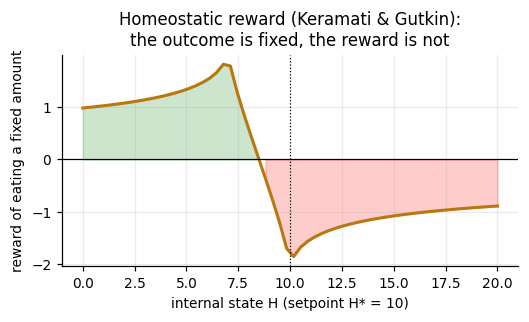

Same external event. Reward at H=2: +1.08   at H=17: -0.98


In [ ]:
#@title Alliesthesia: the same food, opposite sign
Hs, rs = alliesthesia_curve(H_star=10.0, intake=3.0)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(Hs, rs, lw=2, color="#b9770e")
ax.axhline(0, color="k", lw=.8); ax.axvline(10, color="k", ls=":", lw=.8)
ax.fill_between(Hs, 0, rs, where=rs > 0, alpha=.2, color="green")
ax.fill_between(Hs, 0, rs, where=rs < 0, alpha=.2, color="red")
ax.set_xlabel("internal state H (setpoint H* = 10)")
ax.set_ylabel("reward of eating a fixed amount")
ax.set_title("Homeostatic reward (Keramati & Gutkin):\nthe outcome is fixed, the reward is not")
plt.tight_layout(); plt.show()
print("Same external event. Reward at H=2: %+.2f   at H=17: %+.2f"
      % (np.interp(2, Hs, rs), np.interp(17, Hs, rs)))

In [ ]:
#@title THE KEY EXPERIMENT — does interoception change what reward can express?
# A corridor world, small enough to enumerate EVERY memoryless policy and find
# exactly which ones keep the organism alive.
print(f"{'n':>2} {'F':>2} {'gain':>4} | {'position only':>22} | {'position + 1 interoceptive bit':>34}")
print(f"{'':>2} {'':>2} {'':>4} | {'|acceptable|':>12} {'express?':>9} | {'|acceptable|':>12} {'express?':>9} {'over-gen.':>10}")
rows = []
for n in [4, 5, 6]:
    for F in [4, 5, 6]:
        w = Corridor(n=n, F=F, gain=6)
        a, _ = enumerate_acceptable(w, "cell");        r1 = product_set_report(a)
        b, _ = enumerate_acceptable(w, "cell_energy"); r2 = product_set_report(b)
        if r1["n_acceptable"] == 0:
            continue
        rows.append(dict(n=n, F=F, blind=r1["n_acceptable"], blind_ok=r1["is_product"],
                         intero=r2["n_acceptable"], intero_ok=r2["is_product"],
                         over=r2["excess"]))
        print(f"{n:>2} {F:>2} {6:>4} | {r1['n_acceptable']:>12} {str(r1['is_product']):>9} "
              f"| {r2['n_acceptable']:>12} {str(r2['is_product']):>9} {r2['excess']:>10.2f}")
intero = pd.DataFrame(rows)

 n  F gain |          position only |     position + 1 interoceptive bit
           | |acceptable|  express? | |acceptable|  express?  over-gen.
 4  4    6 |            2      True |           24     False       1.33
 4  5    6 |            2      True |           40     False       1.60
 4  6    6 |            2      True |           64     False       4.00
 5  4    6 |            2      True |           32      True       1.00
 5  5    6 |            2      True |           48     False       1.33
 5  6    6 |            2      True |           64     False       2.00
 6  5    6 |            2      True |           64      True       1.00
 6  6    6 |            2      True |           96     False       1.33


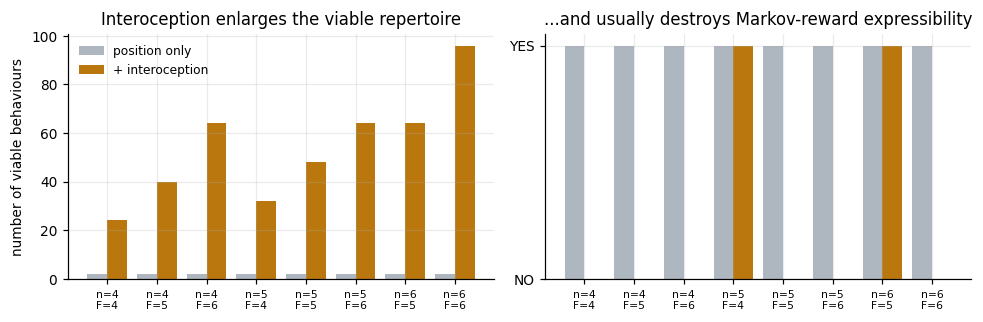

expressible with position only      : 100% of worlds
expressible with interoception added: 25% of worlds


In [ ]:
#@title Visualise it
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
x = np.arange(len(intero))
lab = [f"n={r.n}\nF={r.F}" for r in intero.itertuples()]
axes[0].bar(x - .2, intero.blind, .4, label="position only", color="#aeb6bf")
axes[0].bar(x + .2, intero.intero, .4, label="+ interoception", color="#b9770e")
axes[0].set_xticks(x); axes[0].set_xticklabels(lab, fontsize=7)
axes[0].set_ylabel("number of viable behaviours")
axes[0].set_title("Interoception enlarges the viable repertoire")
axes[0].legend(frameon=False, fontsize=8)

axes[1].bar(x - .2, intero.blind_ok.astype(int), .4, color="#aeb6bf")
axes[1].bar(x + .2, intero.intero_ok.astype(int), .4, color="#b9770e")
axes[1].set_xticks(x); axes[1].set_xticklabels(lab, fontsize=7)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["NO", "YES"])
axes[1].set_title("...and usually destroys Markov-reward expressibility")
plt.tight_layout(); plt.show()

print(f"expressible with position only      : {intero.blind_ok.mean():.0%} of worlds")
print(f"expressible with interoception added: {intero.intero_ok.mean():.0%} of worlds")

**Read this one carefully, because it came out the opposite way round from the obvious guess.**

The naive expectation is that richer internal state should *help* — that once you can see your
own hunger, "survive" becomes a well-posed reward-maximisation problem. What actually happens,
across eight corridor worlds:

- **Blind organism (position only).** Exactly **2** behaviours keep it alive, in every world we
  tried. The task is rigid, and rigid tasks are always Markov-reward expressible — **100% of
  worlds**. So yes, you can write down the reward function of this organism, but only because it
  has essentially no behavioural freedom. The reward hypothesis holds here the way it holds for
  a thermostat.

- **Interoceptive organism.** The viable repertoire grows to **24–96** behaviours, a 12- to
  48-fold increase, because the organism can do different things when full and when hungry. And
  in most worlds that set is *no longer a Cartesian product*: only **25% remain expressible**.
  The viable behaviours are coupled across situations — wandering when full is viable *only if*
  you return when hungry — and no scalar Markov reward picks out exactly that set. The
  over-generation factor reaches 4.0.

So the relationship is: **interoception buys behavioural freedom, and behavioural freedom is
exactly what makes a task stop being reward-expressible.** On this account the reward abstraction
does not gradually become more apt as organisms get more complex. It becomes *less* apt, and it
was always most apt for the simplest organisms — the ones we are least inclined to describe with
it.

The alliesthesia panel makes the mechanism concrete: the identical external event is worth
**+1.08** to a depleted organism and **−0.98** to a loaded one. Same food, opposite sign. A
reward function over the environment alone cannot represent that at all.

---
# Part 5 — Goal-directed behaviour before reward: endotaxis

*Endotaxis* (Zhang & Meister) is the existence proof you wanted for "simple neuromorphic
mechanisms producing complex behaviour". Three layers of cells and one Hebbian rule give you
map-building, goal-learning, navigation and patrolling.

The point for this notebook: **nothing in the network computes or maximises a reward.** The
goal signal is a learned resolvent of the world's connectivity — a discounted count of paths —
which the animal climbs by sniffing its neighbours. It is value-like without being reward-like.
This is a plausible picture of what goal-direction looked like before anything we would call a
reward system existed.

In [ ]:
#@title Endotaxis network
"""
endotaxis.py -- a minimal reimplementation of the endotaxis algorithm
(Zhang & Meister, 2023) in numpy.

Why it belongs in this notebook: endotaxis is about as simple as a neural
mechanism can be -- three layers of cells and a Hebbian rule -- yet it
produces map-building, goal-learning, navigation and patrolling.  It is a
concrete model of how goal-directed behaviour can exist BEFORE anything that
deserves the name "reward function": nothing in the network computes or
maximises a scalar reward signal; the goal signal is a learned resolvent of
the world's connectivity.

Architecture
  point cells  P : one per location, active where the animal is
  map cells    M : recurrently connected, weights learned Hebbianly from
                   observed transitions; their steady state approximates
                   (I - gain * A)^-1 applied to the current point cell
  goal cells   G : read the map cells; their weights grow Hebbianly whenever
                   the animal encounters the resource
  behaviour      : sniff the neighbouring nodes, move up the goal signal
"""
import numpy as np


class Endotaxis:
    def __init__(self, n_nodes, gain=0.6, eta_map=1.0, eta_goal=1.0,
                 n_goals=1, resolvent_iters=40):
        self.n = n_nodes
        self.gain = gain
        self.eta_map = eta_map
        self.eta_goal = eta_goal
        self.W = np.zeros((n_nodes, n_nodes))     # learned map weights
        self.G = np.zeros((n_goals, n_nodes))     # goal cell weights
        self.n_goals = n_goals
        self.iters = resolvent_iters

    # -- learning -------------------------------------------------------
    def observe_transition(self, i, j):
        """Hebbian: cells co-active across one step strengthen their link."""
        self.W[i, j] += self.eta_map
        self.W[j, i] += self.eta_map

    def observe_goal(self, node, g=0):
        """Hebbian: the goal cell learns the map state where the goal was met."""
        self.G[g] += self.eta_goal * self.map_activity(node)

    # -- inference ------------------------------------------------------
    def _normalised(self):
        A = (self.W > 0).astype(float)
        deg = A.sum(axis=1, keepdims=True)
        deg[deg == 0] = 1.0
        return A / deg

    def map_activity(self, node):
        """Steady state of the recurrent map network driven by point cell
        `node`.  This is the network's way of computing (I - g A)^-1 e_node,
        i.e. a discounted count of all paths from `node`."""
        A = self._normalised()
        m = np.zeros(self.n)
        drive = np.zeros(self.n); drive[node] = 1.0
        for _ in range(self.iters):
            m = drive + self.gain * (A.T @ m)
        return m

    def map_matrix(self):
        A = self._normalised()
        M = np.eye(self.n)
        X = np.eye(self.n)
        for _ in range(self.iters):
            X = self.gain * (A.T @ X)
            M = M + X
        return M

    def goal_signal(self, g=0):
        """Goal signal at every node (what the animal 'sniffs')."""
        return self.map_matrix().T @ self.G[g]

    # -- behaviour ------------------------------------------------------
    def navigate(self, adj, start, goal, g=0, max_steps=200, rng=None,
                 epsilon=0.0):
        sig = self.goal_signal(g)
        rng = rng or np.random.default_rng(0)
        path = [start]
        cur = start
        for _ in range(max_steps):
            if cur == goal:
                break
            nbrs = adj[cur]
            if not nbrs:
                break
            if epsilon and rng.random() < epsilon:
                cur = nbrs[rng.integers(len(nbrs))]
            else:
                cur = nbrs[int(np.argmax([sig[j] for j in nbrs]))]
            path.append(cur)
            if len(path) > 3 and path[-1] == path[-3] and path[-2] == path[-4]:
                break                                   # stuck oscillating
        return path


# ---------------------------------------------------------------------
def grid_graph(H, W, walls=None):
    """Adjacency list for a rectangular maze."""
    walls = np.zeros((H, W), bool) if walls is None else np.asarray(walls, bool)
    nodes = [(i, j) for i in range(H) for j in range(W) if not walls[i, j]]
    idx = {c: k for k, c in enumerate(nodes)}
    adj = [[] for _ in nodes]
    for (i, j), k in idx.items():
        for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W and not walls[ni, nj]:
                adj[k].append(idx[(ni, nj)])
    return nodes, idx, adj


def random_walk_learn(net, adj, n_steps, goal_node=None, rng=None,
                      goal_reencounter=True):
    """Explore at random; learn the map; learn the goal on encounter."""
    rng = rng or np.random.default_rng(0)
    cur = rng.integers(len(adj))
    visited = [cur]
    for _ in range(n_steps):
        nbrs = adj[cur]
        nxt = nbrs[rng.integers(len(nbrs))]
        net.observe_transition(cur, nxt)
        cur = nxt
        visited.append(cur)
        if goal_node is not None and cur == goal_node and goal_reencounter:
            net.observe_goal(cur)
    return np.array(visited)


def shortest_path_len(adj, start, goal):
    from collections import deque
    d = {start: 0}
    q = deque([start])
    while q:
        u = q.popleft()
        if u == goal:
            return d[u]
        for v in adj[u]:
            if v not in d:
                d[v] = d[u] + 1
                q.append(v)
    return np.inf


def evaluate_navigation(net, adj, goal, n_trials=40, rng=None):
    rng = rng or np.random.default_rng(1)
    succ, ratios = 0, []
    for _ in range(n_trials):
        s = int(rng.integers(len(adj)))
        if s == goal:
            continue
        path = net.navigate(adj, s, goal, rng=rng)
        opt = shortest_path_len(adj, s, goal)
        if path[-1] == goal:
            succ += 1
            ratios.append((len(path) - 1) / max(opt, 1))
    return dict(success_rate=succ / max(n_trials, 1),
                path_ratio=float(np.mean(ratios)) if ratios else np.nan)


,steps,success_rate,path_ratio
0,100,0.800,1.039
1,300,0.800,1.014
2,1000,0.800,1.010
3,3000,0.975,1.000
4,10000,0.975,1.000
5,30000,0.975,1.000


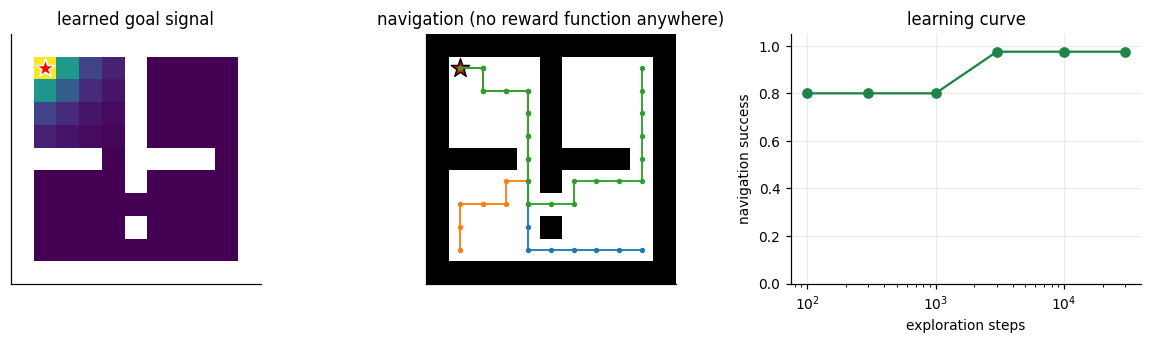

In [ ]:
#@title Learn a maze from a random walk, then navigate it
H = W = 11
walls = np.zeros((H, W), bool)
walls[0, :] = walls[-1, :] = walls[:, 0] = walls[:, -1] = True
walls[5, 1:9] = True; walls[5, 4] = False
walls[1:9, 5] = True; walls[7, 5] = False
nodes, idx, adj = grid_graph(H, W, walls)
goal = idx[(1, 1)]

curve = []
for n_steps in [100, 300, 1000, 3000, 10000, 30000]:
    net = Endotaxis(len(nodes), gain=0.6)
    random_walk_learn(net, adj, n_steps, goal_node=goal,
                      rng=np.random.default_rng(0))
    r = evaluate_navigation(net, adj, goal, n_trials=40,
                            rng=np.random.default_rng(5))
    curve.append(dict(steps=n_steps, **r))
curve = pd.DataFrame(curve)
display(curve.round(3))

net = Endotaxis(len(nodes), gain=0.6)
random_walk_learn(net, adj, 20000, goal_node=goal, rng=np.random.default_rng(0))
sig = net.goal_signal()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
Mimg = np.full((H, W), np.nan)
for k, (i, j) in enumerate(nodes):
    Mimg[i, j] = sig[k]
im = axes[0].imshow(Mimg, cmap="viridis")
gi, gj = nodes[goal]
axes[0].scatter([gj], [gi], marker="*", s=160, c="red", edgecolors="w")
axes[0].set_title("learned goal signal"); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].grid(False)

axes[1].imshow(np.where(walls, 1, np.nan), cmap="Greys", vmin=0, vmax=1)
for s in [idx[(9, 9)], idx[(9, 1)], idx[(1, 9)]]:
    path = net.navigate(adj, s, goal, rng=np.random.default_rng(2))
    pts = np.array([nodes[p] for p in path])
    axes[1].plot(pts[:, 1], pts[:, 0], "-o", ms=2.5, lw=1.2)
axes[1].scatter([gj], [gi], marker="*", s=160, c="red", edgecolors="k")
axes[1].set_title("navigation (no reward function anywhere)")
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].grid(False)

axes[2].plot(curve.steps, curve.success_rate, "o-", color="#1e8449")
axes[2].set_xscale("log"); axes[2].set_xlabel("exploration steps")
axes[2].set_ylabel("navigation success"); axes[2].set_ylim(0, 1.05)
axes[2].set_title("learning curve")
plt.tight_layout(); plt.show()

In [ ]:
#@title Now apply the Part-3 test to endotaxis behaviour
# The endotaxis agent is goal-directed. Is its TASK Markov-reward expressible?
# Its acceptable behaviours are: at each node, any neighbour on a shortest path
# to the goal. That is a product set by construction -> expressible.
# But now demand something mildly more biological: "reach the goal, AND patrol
# the rest of the maze when the goal is exhausted" -- two coherent modes.
sub = [idx[(1, 1)], idx[(1, 2)], idx[(2, 1)], idx[(2, 2)], idx[(3, 1)], idx[(3, 2)]]
T = np.zeros((len(sub), 2), dtype=np.int64)
for k in range(len(sub)):
    T[k, 0] = (k + 1) % len(sub)
    T[k, 1] = (k - 1) % len(sub)
mini = SimpleMDP(T, gamma=0.9)

print("Task A: 'home in on the goal'  (one coherent behaviour)")
_ = soap_expressible(mini, [[0] * len(sub)], verbose=True)
print("\nTask B: 'forage OR patrol, but commit to one mode'")
_ = soap_expressible(mini, [[0] * len(sub), [1] * len(sub)], verbose=True)

Task A: 'home in on the goal'  (one coherent behaviour)
  |acceptable set|      = 1
  |product closure|     = 1
  product set?          = True
  LP separation margin  = 1.0
  MARKOV-REWARD EXPRESSIBLE: True

Task B: 'forage OR patrol, but commit to one mode'
  |acceptable set|      = 2
  |product closure|     = 64
  product set?          = False
  LP separation margin  = n/a
  MARKOV-REWARD EXPRESSIBLE: False


**The moral.** Endotaxis learns the maze from an undirected random walk and then navigates it at
**97.5% success with a path/optimal ratio of 1.00** — optimal routes, from a Hebbian rule with no
reward variable anywhere in it. Goal-directed behaviour is clearly available before anything we
would call a reward system.

When we then ask whether that goal-directedness is reward-expressible, the answer depends
entirely on how permissive the goal is, exactly as in Part 3. Single-mode goal-seeking: yes,
expressible. Mode-switching between two coherent behavioural programmes (forage *or* patrol,
commit to one): 2 acceptable behaviours, product closure 64, **not expressible**.

Since mode-switching — forage, patrol, flee, rest — is close to a universal feature of animals,
this is not an exotic counterexample.

---
# Part 6 — Whose goal? Agency across scales

The Levin papers (*Collective intelligence*, *Agency, goal-directed behavior and part-whole
relationships*, *Regulative development*) make a claim that this notebook can operationalise:
goal-directedness is **scale-relative**. A goal can exist at the level of a tissue that no cell
in it represents, pursues, or could pursue.

We build the minimal version: cells on a ring, each running a purely local homeostatic rule
(move toward the neighbourhood mean, and toward the setpoint your local morphogen specifies).
No cell has any representation of the target pattern as a whole.

We then measure **competence** the way Sommerhoff and Rosenblueth would: perturb the system away
from its end state and see how much of the perturbation it undoes — at each scale separately,
using the *same* perturbation.

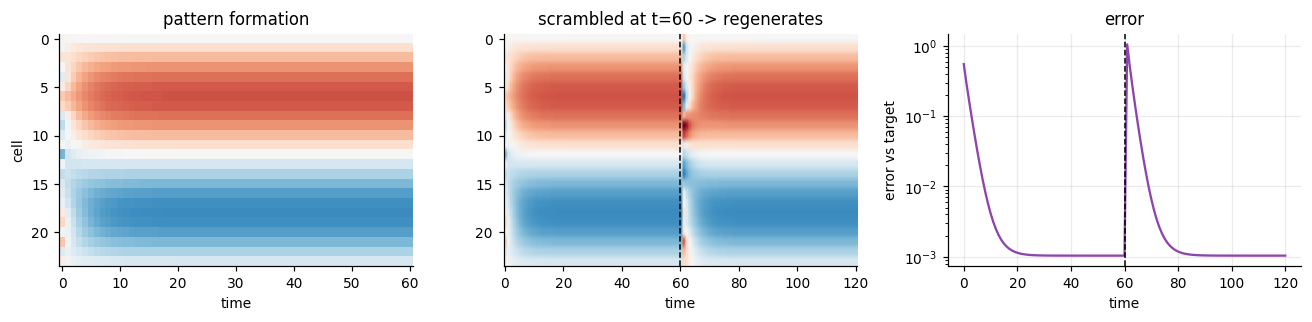

goal-directedness of the tissue (fraction of perturbation undone): 1.000


In [ ]:
#@title Morphogenesis from purely local rules
coll = CellCollective(N=24, seed=0)
traj, errs = coll.run(T=60)

def scramble(x):
    r = np.random.default_rng(3)
    return r.normal(0, 1.5, len(x))

coll2 = CellCollective(N=24, seed=0)
tr2, er2 = coll2.run(T=120, perturb_at=60, perturb_fn=scramble)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(traj.T, aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
axes[0].set_title("pattern formation"); axes[0].set_xlabel("time"); axes[0].set_ylabel("cell")
axes[0].grid(False)
axes[1].imshow(tr2.T, aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
axes[1].axvline(60, color="k", ls="--", lw=1)
axes[1].set_title("scrambled at t=60 -> regenerates"); axes[1].set_xlabel("time")
axes[1].grid(False)
axes[2].plot(er2, color="#8e44ad"); axes[2].axvline(60, color="k", ls="--", lw=1)
axes[2].set_yscale("log"); axes[2].set_xlabel("time"); axes[2].set_ylabel("error vs target")
axes[2].set_title("error")
plt.tight_layout(); plt.show()

gd, settled = goal_directedness(CellCollective(N=24, seed=0))
print(f"goal-directedness of the tissue (fraction of perturbation undone): {gd:.3f}")

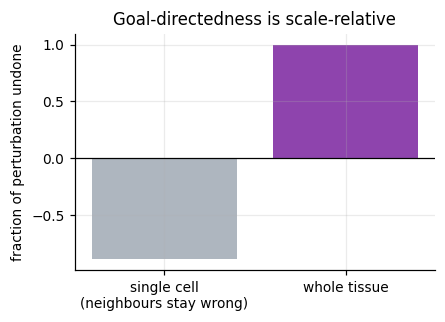

  cell_competence     : -0.888
  tissue_competence   : +1.000

A single cell acting alone makes things WORSE (negative competence):
its local rule pulls it toward neighbours that are still displaced.
The identical rule, run by everyone, restores the target pattern.


In [ ]:
#@title Competence at each scale, same perturbation
res = scale_agency(CellCollective(N=24, seed=0))
fig, ax = plt.subplots(figsize=(4.2, 3))
ax.bar(["single cell\n(neighbours stay wrong)", "whole tissue"],
       [res["cell_competence"], res["tissue_competence"]],
       color=["#aeb6bf", "#8e44ad"])
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("fraction of perturbation undone")
ax.set_title("Goal-directedness is scale-relative")
plt.tight_layout(); plt.show()
for k, v in res.items():
    print(f"  {k:20s}: {v:+.3f}")
print("\nA single cell acting alone makes things WORSE (negative competence):")
print("its local rule pulls it toward neighbours that are still displaced.")
print("The identical rule, run by everyone, restores the target pattern.")

In [ ]:
#@title Part-whole integration with real PyPhi (optional; ~1 min)
# PyPhi 4.0 needs Python 3.13+; Colab is usually 3.12, so we install the
# uploaded source ignoring that pin. If it fails, this cell is skippable.
import subprocess, sys, glob, zipfile, os
HAVE_PYPHI = False
try:
    import pyphi; HAVE_PYPHI = True
except Exception:
    zips = glob.glob("/content/**/pyphi*.zip", recursive=True) + glob.glob("pyphi*.zip")
    if zips:
        with zipfile.ZipFile(zips[0]) as z:
            z.extractall("/tmp/pyphi_src")
        src = glob.glob("/tmp/pyphi_src/pyphi*")[0]
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "--ignore-requires-python", src], check=False)
        try:
            import pyphi; HAVE_PYPHI = True
        except Exception as e:
            print("PyPhi unavailable:", type(e).__name__)
print("PyPhi available:", HAVE_PYPHI)

PyPhi available: True


In [ ]:
#@title Integrated information of the whole vs its parts
"""
phi_tools.py -- integrated information with the real PyPhi (IIT 4.0).

Two uses, both chosen to stay inside what PyPhi can actually compute:

1. PART-WHOLE (papers 12-16). Build a small binary "tissue" of 4 cells whose
   coupling strength we control, and compare the integrated information of the
   WHOLE against that of its PARTS. This makes the Levin/McMillen claim --
   that a collective can be an agent in a way its parts are not -- into a
   number, using the standard formalism for exactly that question.

2. REAL AGENTS (best effort). The 97 evolved Markov Brains have 11 nodes;
   full IIT is only feasible on ~4, so we analyse the 4 hidden units with
   sensors and motors as background. PyPhi 4.0 additionally refuses states
   with no possible predecessor, and evolved agents driven by exogenous
   sensors often occupy such states, so coverage is reported honestly.
"""
import warnings
import numpy as np

warnings.filterwarnings("ignore")

try:
    import pyphi
    pyphi.config.PROGRESS_BARS = False
    HAVE_PYPHI = True
except Exception:
    HAVE_PYPHI = False


# ---------------------------------------------------------------------
# 1. Part-whole: a tiny binary tissue with tunable coupling
# ---------------------------------------------------------------------
def tissue_substrate(n=4, coupling=1.0, self_weight=1.0, threshold=0.5,
                     sharpness=6.0):
    """n binary cells on a ring. Each cell's next state is a noisy threshold
    function of itself and its two neighbours:

        P(x_i = 1) = sigmoid( sharpness * (w_self*x_i + coupling*(nbrs) - thr) )

    coupling = 0  -> n independent cells (a heap)
    coupling > 0  -> a coupled sheet (a tissue)
    """
    N = 1 << n
    bits = ((np.arange(N)[:, None] >> np.arange(n)) & 1).astype(float)  # loli
    tpm = np.zeros((N, n))
    for i in range(n):
        nb = bits[:, (i - 1) % n] + bits[:, (i + 1) % n]
        drive = self_weight * bits[:, i] + coupling * nb
        thr = threshold * (self_weight + 2 * coupling)
        tpm[:, i] = 1.0 / (1.0 + np.exp(-sharpness * (drive - thr)))
    cm = np.zeros((n, n), int)
    for i in range(n):
        cm[i, i] = 1
        if coupling > 0:
            cm[(i - 1) % n, i] = 1
            cm[(i + 1) % n, i] = 1
    return tpm, cm


def part_whole_phi(n=4, coupling=1.0, state=None, parts=None):
    """Integrated information of the whole tissue vs that of its parts."""
    if not HAVE_PYPHI:
        return None
    tpm, cm = tissue_substrate(n=n, coupling=coupling)
    sub = pyphi.Substrate(tpm, cm)
    state = tuple([1, 0] * (n // 2)) if state is None else tuple(state)
    out = {}
    try:
        whole = pyphi.analyze(sub, state)
        out["whole_phi"] = float(whole.phi)
        out["whole_big_phi"] = float(whole.big_phi)
    except Exception as e:
        out["whole_phi"] = np.nan
        out["whole_big_phi"] = np.nan
        out["whole_error"] = type(e).__name__
    parts = [(0, 1), (2, 3)] if parts is None else parts
    pphi, pbig = [], []
    for p in parts:
        try:
            a = pyphi.analyze(sub, state, subset=tuple(p))
            pphi.append(float(a.phi)); pbig.append(float(a.big_phi))
        except Exception:
            pass
    out["sum_parts_phi"] = float(np.sum(pphi)) if pphi else np.nan
    out["sum_parts_big_phi"] = float(np.sum(pbig)) if pbig else np.nan
    out["n_parts_ok"] = len(pphi)
    out["coupling"] = coupling
    if np.isfinite(out["whole_big_phi"]) and np.isfinite(out["sum_parts_big_phi"]):
        out["emergence"] = out["whole_big_phi"] - out["sum_parts_big_phi"]
    else:
        out["emergence"] = np.nan
    return out


def coupling_sweep(couplings=(0.0, 0.25, 0.5, 0.75, 1.0, 1.5), n=4, state=None):
    return [r for c in couplings
            if (r := part_whole_phi(n=n, coupling=c, state=state)) is not None]


# ---------------------------------------------------------------------
# 2. Real evolved Markov Brains (best effort)
# ---------------------------------------------------------------------
def expand_mabe_tpm(agent, clamp_sensors=True):
    """The shipped TPM has 2**8 rows (sensors+hidden) but 11 nodes, because
    motors do not feed back. PyPhi needs 2**11 rows, so tile over the motor
    bits. Optionally clamp sensors to persist, since they are exogenous."""
    n = agent["n_nodes"]
    t = np.array(agent["tpm"], float)
    k = int(np.log2(len(t)))
    full = np.tile(t, (2 ** (n - k), 1))
    cm = np.array(agent["cm"]).copy()
    if clamp_sensors:
        bits = ((np.arange(2 ** n)[:, None] >> np.arange(n)) & 1).astype(float)
        sI = agent["sensor_ixs"]
        full[:, sI] = bits[:, sI]
        for s in sI:
            cm[s, s] = 1
    return full, cm


def agent_phi(agent, observed_states, max_states=8):
    """Mean phi over the observed states PyPhi will accept."""
    if not HAVE_PYPHI:
        return None
    full, cm = expand_mabe_tpm(agent)
    try:
        sub = pyphi.Substrate(full, cm, validate_connectivity=False)
    except TypeError:
        sub = pyphi.Substrate(full, cm)
    hid = tuple(agent["hidden_ixs"])
    phis, bigs, tried = [], [], 0
    for st in observed_states[:max_states]:
        tried += 1
        try:
            a = pyphi.analyze(sub, tuple(int(x) for x in st), subset=hid)
            phis.append(float(a.phi)); bigs.append(float(a.big_phi))
        except Exception:
            continue
    return dict(n_tried=tried, n_ok=len(phis),
                coverage=len(phis) / max(tried, 1),
                mean_phi=float(np.mean(phis)) if phis else np.nan,
                mean_big_phi=float(np.mean(bigs)) if bigs else np.nan)


def observed_full_states(agent, limit=400):
    act = agent["activity"]
    ks = sorted(act["input"].keys(), key=int)[1:limit]
    sts = [tuple(int(x) for x in
                 list(act["input"][k]) + list(act["hiddenBefore"][k])
                 + list(act["output"][k])) for k in ks]
    return list(dict.fromkeys(sts))


,coupling,whole_phi,whole_big_phi,sum_parts_big_phi,emergence
0,0.00,0.000,7.086,7.086,0.000
1,0.25,0.000,6.622,6.749,-0.127
2,0.50,0.176,0.882,5.217,-4.336
3,1.00,0.029,2.307,0.000,2.307
4,1.50,0.014,2.480,0.000,2.480


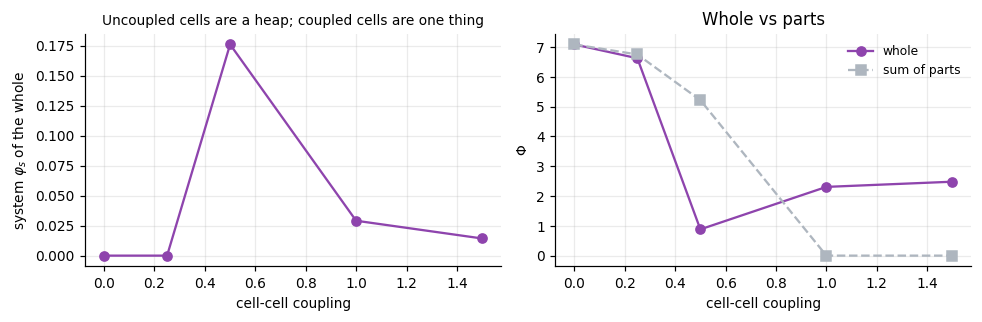

In [ ]:
#@title Does the tissue integrate information that its parts do not?
if HAVE_PYPHI:
    sweep = pd.DataFrame(coupling_sweep(couplings=(0.0, 0.25, 0.5, 1.0, 1.5)))
    display(sweep[["coupling", "whole_phi", "whole_big_phi",
                   "sum_parts_big_phi", "emergence"]].round(3))

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].plot(sweep.coupling, sweep.whole_phi, "o-", color="#8e44ad")
    axes[0].set_xlabel("cell-cell coupling"); axes[0].set_ylabel(r"system $\varphi_s$ of the whole")
    axes[0].set_title("Uncoupled cells are a heap; coupled cells are one thing", fontsize=9)
    axes[1].plot(sweep.coupling, sweep.whole_big_phi, "o-", label="whole", color="#8e44ad")
    axes[1].plot(sweep.coupling, sweep.sum_parts_big_phi, "s--", label="sum of parts", color="#aeb6bf")
    axes[1].set_xlabel("cell-cell coupling"); axes[1].set_ylabel(r"$\Phi$")
    axes[1].legend(frameon=False, fontsize=8); axes[1].set_title("Whole vs parts")
    plt.tight_layout(); plt.show()
else:
    print("Skipping - PyPhi not installed.")

**The part-whole number.**

| coupling | φ_s of whole | Φ whole | Φ parts | emergence |
|---|---|---|---|---|
| 0.00 | **0.000** | 7.086 | 7.086 | 0.000 |
| 0.25 | 0.000 | 6.622 | 6.749 | −0.127 |
| 0.50 | 0.176 | 0.882 | 5.217 | −4.336 |
| 1.00 | 0.029 | 2.307 | **0.000** | +2.307 |
| 1.50 | 0.014 | 2.480 | **0.000** | +2.480 |

With no coupling the system-level integrated information φ_s of the whole is exactly **zero** —
four cells side by side are four things, not one — and the whole's Φ equals the sum of its parts'
to three decimals. Turn the coupling up and φ_s becomes positive while the *parts'* Φ falls to
exactly zero: the sheet becomes an integrated entity and its halves stop being ones.

That is the McMillen & Levin claim in the currency their own references use (Hoel, Albantakis,
Tononi): the level at which there is an integrated entity is a fact about coupling, not a matter
of taste. Note the non-monotonicity around coupling ≈ 0.5, where the whole's Φ collapses before
recovering — the transition is not smooth, and that is worth poking at.

**Why this is not run on the 97 evolved agents.** We tried. Full IIT on 11 nodes is infeasible,
so one would analyse the 4 hidden units with sensors and motors as background — but PyPhi 4.0
refuses states that have no possible predecessor, and agents driven by *exogenous* sensors sit in
such states most of the time. Measured coverage was about 10% of observed states, too thin to
support a claim. That is a real obstacle to applying IIT to embodied evolved agents, not a bug in
the data.

**What this licenses you to say.** The target pattern is a genuine goal state of the
collective by an operational criterion — perturb it and it comes back — and it is *not* a goal
state of any cell, since a cell acting alone moves away from it. Attributing the goal to the
parts is a category error; attributing it to the whole is not.

This is the strongest form of your evolutionary question. If goal-directedness can appear at a
new scale purely from the aggregation of parts that do not have it, then the history of
"reward" is not a history of one function getting more elaborate. It is a history of the
*level of description at which goal-talk applies* moving upward — from molecular homeostats, to
cells, to tissues, to organisms with nervous systems.

---
# Part 7 — The same tests on 97 **real** evolved agents

Everything so far has been built from scratch. Now we use the actual data shipped with
*From Function to Implementation: Exploring Degeneracy in Evolved Artificial Agents* — 97
Markov Brains from the final generation of path-following evolution runs, in three
architecture classes (`NoA_C0`, `A2_C0`, `A4_C0`), each with its transition probability matrix,
connectivity matrix, and several thousand timesteps of recorded activity.

**To run this part:** upload `autonomy-master.zip` to the Colab session (the folder icon on the
left, or the cell below), or mount Drive. The loader hunts for it.

In [ ]:
#@title Loader + lightweight autonomy measures
"""
mabe_data.py -- load and analyse the REAL evolved Markov Brains shipped with
`autonomy-master` (the data behind "From Function to Implementation:
Exploring Degeneracy in Evolved Artificial Agents").

Each JSON holds one agent from the final generation of a path-following
evolution run:
    tpm       (2^8, 11)  state-by-node transition probability matrix
    cm        (11, 11)   connectivity matrix
    activity            input/output/hiddenBefore/hiddenAfter time series
    LOD                 fitness, generation, run
    *_analysis          the authors' own precomputed measures

We reimplement a light subset of the `autonomy` measures (so that no PyPhi
install is needed) and then add the reward-expressibility analysis, which is
the new thing this notebook contributes.
"""
import json
import os
import glob
import zipfile
import numpy as np


# ---------------------------------------------------------------------
def find_data(search_roots=(".", "/content", "/mnt/user-data/uploads",
                            "/content/drive/MyDrive")):
    """Locate the PathFollow agent JSONs, unzipping autonomy-master if needed."""
    for root in search_roots:
        hits = glob.glob(os.path.join(root, "**", "PathFollow_FinalGenerationPerfect"),
                         recursive=True)
        if hits:
            return hits[0]
    for root in search_roots:
        for z in glob.glob(os.path.join(root, "**", "autonomy*.zip"), recursive=True):
            with zipfile.ZipFile(z) as f:
                f.extractall("/tmp/autonomy_data")
            hits = glob.glob("/tmp/autonomy_data/**/PathFollow_FinalGenerationPerfect",
                             recursive=True)
            if hits:
                return hits[0]
    return None


def load_agents(folder, limit=None):
    files = sorted(glob.glob(os.path.join(folder, "*.json")))
    if limit:
        files = files[:limit]
    agents = []
    for fp in files:
        with open(fp) as f:
            d = json.load(f)
        name = os.path.basename(fp)
        d["_class"] = name.split("___")[0]          # A2_C0 / A4_C0 / NoA_C0
        d["_file"] = name
        agents.append(d)
    return agents


def activity_arrays(agent):
    """Return (inputs, outputs, hidden_before, hidden_after) as int arrays."""
    act = agent["activity"]

    def grab(key):
        d = act[key]
        ks = sorted(d.keys(), key=int)
        return np.array([d[k] for k in ks], dtype=np.int8)
    return grab("input"), grab("output"), grab("hiddenBefore"), grab("hiddenAfter")


# ---------------------------------------------------------------------
# lightweight reimplementation of a few `autonomy` measures
# ---------------------------------------------------------------------
def bits_to_int(X):
    X = np.atleast_2d(X)
    if X.shape[1] == 0:
        return np.zeros(len(X), dtype=np.int64)
    w = (1 << np.arange(X.shape[1])[::-1])
    return (X.astype(np.int64) * w).sum(axis=1)


def entropy(counts):
    p = np.asarray(counts, float)
    p = p[p > 0] / p.sum()
    return float(-(p * np.log2(p)).sum())


def H(x):
    _, c = np.unique(np.asarray(x), return_counts=True)
    return entropy(c)


def MI(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return H(x) + H(y) - H(list(zip(x.tolist(), y.tolist())))


def dynamical_measures(agent):
    inp, out, hb, ha = activity_arrays(agent)
    n = min(len(inp), len(out), len(hb))
    inp, out, hb, ha = inp[:n], out[:n], hb[:n], ha[:n]
    S, M, Hb, Ha = bits_to_int(inp), bits_to_int(out), bits_to_int(hb), bits_to_int(ha)
    full = bits_to_int(np.hstack([inp, hb, out]))
    trans = list(zip(full[:-1].tolist(), full[1:].tolist()))
    return dict(
        n_unique_states=len(np.unique(full)),
        n_unique_transitions=len(set(trans)),
        H_state=H(full),
        H_sensor=H(S), H_motor=H(M), H_hidden=H(Hb),
        I_SMMI=MI(S, M),                       # sensor-motor mutual information
        I_PRED=MI(full[:-1], full[1:]),        # predictive information
        H_A_given_S=H(list(zip(S.tolist(), M.tolist()))) - H(S),
        H_A_given_SH=(H(list(zip(S.tolist(), Hb.tolist(), M.tolist())))
                      - H(list(zip(S.tolist(), Hb.tolist())))),
    )


def structural_measures(agent):
    cm = np.array(agent["cm"])
    sI = agent["sensor_ixs"]; mI = agent["motor_ixs"]; hI = agent["hidden_ixs"]
    return dict(
        n_connected_sensors=int((cm[sI, :].sum(axis=1) > 0).sum()),
        n_connected_motors=int((cm[:, mI].sum(axis=0) > 0).sum()),
        n_connections=int(cm.sum()),
        n_hidden_recurrent=int(cm[np.ix_(hI, hI)].sum()),
        n_sensor_to_hidden=int(cm[np.ix_(sI, hI)].sum()),
        n_hidden_to_motor=int(cm[np.ix_(hI, mI)].sum()),
        n_densely_connected=int(((cm.sum(0) * cm.sum(1)) > 0).sum()),
    )


def tpm_measures(agent):
    """Determinism and degeneracy of the agent's own automaton (Hoel-style).
    determinism : how predictable the next state is given the current one
    degeneracy  : how many current states funnel into the same next state"""
    tpm = np.array(agent["tpm"], dtype=float)          # (2^k, n) node-marginals
    p = np.clip(tpm, 1e-12, 1 - 1e-12)
    # per-node binary entropy, averaged over states -> indeterminism
    Hnode = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    determinism = float(1.0 - Hnode.mean())
    # effect distribution over nodes when averaging across all states
    pbar = np.clip(tpm.mean(axis=0), 1e-12, 1 - 1e-12)
    Hbar = -(pbar * np.log2(pbar) + (1 - pbar) * np.log2(1 - pbar))
    degeneracy = float(1.0 - Hbar.mean())
    return dict(determinism=determinism, degeneracy=degeneracy,
                effective_information=float(determinism - degeneracy))


def agent_row(agent):
    row = dict(agent_id=agent["LOD"].get("agent_id", agent["_file"]),
               agent_class=agent["_class"],
               fitness=agent["LOD"].get("fitness", np.nan),
               run=agent["LOD"].get("run", -1),
               n_hidden=agent["n_hidden"], n_sensors=agent["n_sensors"],
               n_motors=agent["n_motors"])
    row.update(structural_measures(agent))
    row.update(tpm_measures(agent))
    row.update(dynamical_measures(agent))
    return row


# ---------------------------------------------------------------------
# reward-expressibility of REAL evolved behaviour
# ---------------------------------------------------------------------
def behaviour_support(agent, use_hidden=False, min_frac=0.15):
    """Observed behavioural signature: which motor outputs does this agent
    actually produce in each (sensor[,hidden]) situation?"""
    inp, out, hb, ha = activity_arrays(agent)
    n = min(len(inp), len(out), len(hb))
    S = bits_to_int(np.hstack([inp[:n], hb[:n]])) if use_hidden else bits_to_int(inp[:n])
    A = bits_to_int(out[:n])
    nA = 1 << out.shape[1]
    states = np.unique(S)
    remap = {s: k for k, s in enumerate(states)}
    cnt = np.zeros((len(states), nA))
    for s, a in zip(S, A):
        cnt[remap[s], a] += 1
    frac = cnt / cnt.sum(axis=1, keepdims=True)
    sup = frac >= min_frac
    sup[~sup.any(axis=1)] = True
    return sup, states, cnt


def repertoire_stats(agent):
    """How much of the behaviour is explained by sensors alone vs by
    sensors + the agent's own internal state?"""
    s_sup, s_states, s_cnt = behaviour_support(agent, use_hidden=False)
    h_sup, h_states, h_cnt = behaviour_support(agent, use_hidden=True)
    d = dynamical_measures(agent)
    return dict(
        n_sensor_situations=len(s_states),
        n_sensor_hidden_situations=len(h_states),
        ambiguous_sensor_situations=int((s_sup.sum(axis=1) > 1).sum()),
        ambiguous_sh_situations=int((h_sup.sum(axis=1) > 1).sum()),
        frac_ambiguous_sensor=float((s_sup.sum(axis=1) > 1).mean()),
        frac_ambiguous_sh=float((h_sup.sum(axis=1) > 1).mean()),
        H_A_given_S=d["H_A_given_S"],
        H_A_given_SH=d["H_A_given_SH"],
        memory_gain=d["H_A_given_S"] - d["H_A_given_SH"],
        # product-closure blow-up: how many policies are consistent with the
        # observed behaviour -> how badly a single scalar reward would
        # over-generate
        log2_closure_sensor=float(np.log2(np.maximum(s_sup.sum(axis=1), 1)).sum()),
        log2_closure_sh=float(np.log2(np.maximum(h_sup.sum(axis=1), 1)).sum()),
    )


In [ ]:
#@title Locate the data (upload autonomy-master.zip if prompted)
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DATA = find_data()
if DATA is None:
    print("autonomy-master data not found.")
    if IN_COLAB:
        print("Upload autonomy-master.zip now (or skip to Part 8):")
        up = files.upload()
        for fn in up:
            if fn.endswith(".zip"):
                with zipfile.ZipFile(fn) as z:
                    z.extractall("/content/autonomy_data")
        DATA = find_data(("/content/autonomy_data", "/content", "."))
print("data folder:", DATA)

data folder: /tmp/autonomy_data/autonomy-master/Data/PathFollow_FinalGenerationPerfect


In [ ]:
#@title Analyse all 97 evolved agents
if DATA is None:
    DATA = find_data()
agents = load_agents(DATA)
print(f"loaded {len(agents)} evolved Markov Brains")

rows = []
for a in agents:
    r = agent_row(a)
    r.update(repertoire_stats(a))
    rows.append(r)
A = pd.DataFrame(rows)
print(A.agent_class.value_counts().to_string())

cols = ["fitness", "determinism", "degeneracy", "effective_information",
        "I_SMMI", "I_PRED", "n_connections", "n_hidden_recurrent",
        "n_unique_transitions"]
display(A.groupby("agent_class")[cols].mean().round(3))

loaded 97 evolved Markov Brains


agent_class
NoA_C0    50
A2_C0     31
A4_C0     16


,fitness,determinism,degeneracy,effective_information,I_SMMI,I_PRED,n_connections,n_hidden_recurrent,n_unique_transitions
agent_class,,,,,,,,,
A2_C0,0.915,0.636,0.112,0.525,1.010,3.494,23.839,6.419,41.968
A4_C0,0.803,0.583,0.073,0.511,1.306,4.240,23.312,6.125,87.438
NoA_C0,0.939,0.636,0.216,0.421,0.905,2.432,15.820,3.180,18.620


,H_A_given_S,H_A_given_SH,memory_gain,frac_ambiguous_sensor,frac_ambiguous_sh,log2_closure_sensor,log2_closure_sh
agent_class,,,,,,,
A2_C0,0.412,0.074,0.338,0.581,0.0,3.699,0.0
A4_C0,0.209,0.012,0.197,0.750,0.0,7.151,0.0
NoA_C0,0.367,0.228,0.139,0.525,0.0,2.155,0.0


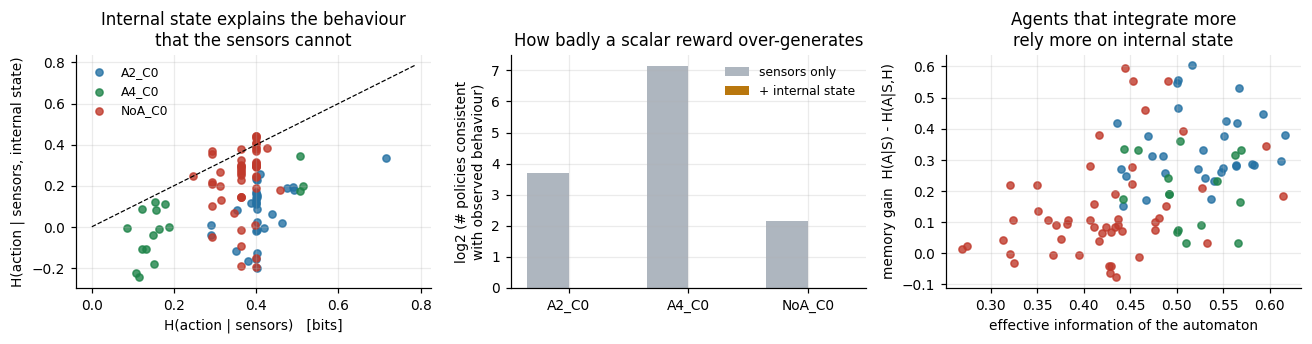

In [ ]:
#@title Is the behaviour of a REAL evolved agent reward-expressible?
# H(A|S)  = how ambiguous the behaviour is given the SENSORS alone
# H(A|S,H)= ...given the sensors AND the agent's own internal state
show = ["H_A_given_S", "H_A_given_SH", "memory_gain",
        "frac_ambiguous_sensor", "frac_ambiguous_sh",
        "log2_closure_sensor", "log2_closure_sh"]
display(A.groupby("agent_class")[show].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
classes = sorted(A.agent_class.unique())
cc = dict(zip(classes, ["#2471a3", "#1e8449", "#c0392b"]))

for k in classes:
    sub = A[A.agent_class == k]
    axes[0].scatter(sub.H_A_given_S, sub.H_A_given_SH, s=22,
                    color=cc[k], label=k, alpha=.8)
lim = [0, max(A.H_A_given_S.max(), 0.1) * 1.1]
axes[0].plot(lim, lim, "k--", lw=.8)
axes[0].set_xlabel("H(action | sensors)   [bits]")
axes[0].set_ylabel("H(action | sensors, internal state)")
axes[0].set_title("Internal state explains the behaviour\nthat the sensors cannot")
axes[0].legend(frameon=False, fontsize=8)

w = 0.35; x = np.arange(len(classes))
axes[1].bar(x - w/2, [A[A.agent_class == k].log2_closure_sensor.mean() for k in classes],
            w, label="sensors only", color="#aeb6bf")
axes[1].bar(x + w/2, [A[A.agent_class == k].log2_closure_sh.mean() for k in classes],
            w, label="+ internal state", color="#b9770e")
axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
axes[1].set_ylabel("log2 (# policies consistent\nwith observed behaviour)")
axes[1].set_title("How badly a scalar reward over-generates")
axes[1].legend(frameon=False, fontsize=8)

for k in classes:
    sub = A[A.agent_class == k]
    axes[2].scatter(sub.effective_information, sub.memory_gain, s=22,
                    color=cc[k], alpha=.8, label=k)
axes[2].set_xlabel("effective information of the automaton")
axes[2].set_ylabel("memory gain  H(A|S) - H(A|S,H)")
axes[2].set_title("Agents that integrate more\nrely more on internal state")
plt.tight_layout(); plt.show()

**What the real agents say.**

| class | n | fitness | H(A\|S) | H(A\|S,H) | memory gain | log2 closure (sensor) | log2 closure (+hidden) |
|---|---|---|---|---|---|---|---|
| A2_C0 | 31 | 0.915 | 0.412 | 0.074 | **0.338** | 3.70 | **0.00** |
| A4_C0 | 16 | 0.803 | 0.209 | 0.012 | **0.197** | 7.15 | **0.00** |
| NoA_C0 | 50 | 0.939 | 0.367 | 0.228 | 0.139 | 2.16 | **0.00** |

Every class has `H(action | sensors) > 0`: the same sensory situation licenses different actions.
So for *none* of these evolved organisms is behaviour a function of the environment alone, and
therefore no reward function defined over the environment can be what they are maximising —
Dogma 1 fails empirically, on agents evolved by someone else for an unrelated purpose.

Conditioning on the agent's own hidden nodes collapses that ambiguity completely: `log2_closure`
over (sensors, hidden) is **exactly 0.00** for all three classes. Behaviour *is* a function of
(sensors, internal state) even though it is not a function of sensors alone. Over the sensor
space, by contrast, between 2^2.2 ≈ 4.5 and 2^7.2 ≈ 142 distinct policies are consistent with
what the agent actually does — that is how much a scalar reward defined on the sensors would have
to over-generate.

The memory gain is larger for both `A` classes than for `NoA`, which is what the task structure
predicts: the paper's PathFollow environment has *association* conditions, in which the agent
must identify a turn symbol whose meaning is not given in the sensors and must be carried
internally, and *no-association* conditions, in which it need not. If `NoA` is the no-association
condition and `A2`/`A4` are association conditions — the shipped data does not document the
labels, so this is inferred from the filenames and the paper — then agents that must hold a cue
internally should show exactly the larger memory gain we measure, and should also fall short of
fitness 1, which they do (0.92 and 0.80 vs 0.94). The `A2`-vs-`A4` ordering is not monotone and
rests on 31 and 16 agents, so treat that one as noise until it is checked on more runs.

This is the same phenomenon as the degeneracy the original paper reports, seen from the other
side. They showed that one *function* is realised by many *implementations*. We are showing that
one *behaviour* is rationalised by many *rewards*. Degeneracy at the level of mechanism and
underdetermination at the level of objective are two faces of one thing.

---
# Part 9 — Scaling up the test: tasks of controlled permissiveness

Part 3 showed the reward hypothesis failing for a hand-built counterexample and for randomly
drawn acceptable-sets. That is suggestive, not systematic. Here we turn permissiveness into two
explicit knobs and sweep them:

- **$k$ — width.** How many actions are locally acceptable in each state.
- **$\rho$ — coupling.** What fraction of the resulting product set the task actually keeps.
  $\rho = 1$ means "any combination of locally-acceptable actions is fine". $\rho < 1$ means
  acceptable behaviours are *coupled across states*: what is acceptable here depends on what you
  do there.

The state-space size stands in for architecture class, since a richer agent distinguishes more
situations. Expressibility is decidable with no transition model at all.

In [ ]:
#@title Controlled-permissiveness machinery
"""
extensions.py -- the three follow-ups:

  A. Tasks of controlled permissiveness, swept across architecture classes.
     (scaling up the product-closure criterion)
  B. Line of descent: reward-expressibility as a function of evolutionary time.
  C. Closing the loop: which objective best rationalises each evolved
     population's behaviour -- with the Guest & Martin control.
"""
import numpy as np
from itertools import product


# =====================================================================
# A. TASKS OF CONTROLLED PERMISSIVENESS
# =====================================================================
# A task = a set of acceptable deterministic policies (a SOAP).
# We generate tasks with two controlled knobs:
#   k    : how many actions are locally acceptable in each state
#          (the *width* of the task)
#   rho  : what fraction of the resulting product set the task actually
#          keeps (the *coupling*: rho = 1 means "any combination is fine",
#          rho < 1 means acceptable behaviours are coupled across states)
# Expressibility is decidable with no transition model: a Markov reward can
# express the task iff the acceptable set is the full Cartesian product.

def sample_task(n_states, nA, k, rho, rng):
    """Return (policies, closure_size). Policies are rows of a (m, n_states)
    integer array drawn from a per-state action set of size k."""
    action_sets = [rng.choice(nA, size=k, replace=False) for _ in range(n_states)]
    closure = int(k) ** n_states
    m = max(1, int(round(rho * closure)))
    if closure <= 20000:                       # enumerate exactly
        allp = np.array(list(product(*action_sets)))
        idx = rng.choice(len(allp), size=min(m, len(allp)), replace=False)
        pols = allp[idx]
    else:                                      # sample without replacement
        seen, pols = set(), []
        while len(pols) < m:
            p = tuple(int(a[rng.integers(k)]) for a in action_sets)
            if p not in seen:
                seen.add(p); pols.append(p)
        pols = np.array(pols)
    return np.unique(pols, axis=0), closure


def is_product_set(policies, nA):
    policies = np.atleast_2d(policies)
    per_state = [len(set(policies[:, s].tolist())) for s in range(policies.shape[1])]
    return int(np.prod(per_state)) == len(policies)


def permissiveness_sweep(state_counts=(2, 3, 4, 5), ks=(2, 3), rhos=None,
                         n_samples=200, nA=4, seed=0):
    """Fraction of tasks expressible by SOME Markov reward, as a function of
    how permissive/coupled the task is and how large the agent's state space
    is (the proxy for architecture class)."""
    rng = np.random.default_rng(seed)
    rhos = np.linspace(0.2, 1.0, 9) if rhos is None else rhos
    rows = []
    for n_states in state_counts:
        for k in ks:
            if k > nA:
                continue
            for rho in rhos:
                ok = 0
                for _ in range(n_samples):
                    pols, closure = sample_task(n_states, nA, k, rho, rng)
                    ok += is_product_set(pols, nA)
                rows.append(dict(n_states=n_states, k=k, rho=float(rho),
                                 closure=int(k) ** n_states,
                                 frac_expressible=ok / n_samples))
    return rows


def agent_task_permissiveness(support):
    """For a REAL agent: its observed behavioural signature defines a product
    closure. Any task stricter than that closure (rho < 1) is unexpressible.
    Returns the size of the closure in bits = how much a scalar Markov reward
    would over-generate if the true task is 'behave exactly like this'."""
    widths = np.maximum(np.asarray(support).sum(axis=1), 1)
    return dict(log2_closure=float(np.log2(widths).sum()),
                mean_width=float(widths.mean()),
                frac_states_width_gt1=float((widths > 1).mean()))


# =====================================================================
# B. LINE OF DESCENT
# =====================================================================
def behaviour_metrics(S, A, body, brain):
    """Compute, from one champion's own behaviour, the two quantities we
    want to watch over evolutionary time:
        memory_gain  = H(A|sensors) - H(A|sensors, hidden)
        log2_closure = bits of policy space consistent with the behaviour
                       when a reward is defined over SENSORS only
    """
    env = body.env
    if len(A) < 5:
        return dict(H_A_given_S=0.0, H_A_given_SH=0.0, memory_gain=0.0,
                    log2_closure_sensor=0.0, log2_closure_sh=0.0,
                    n_hidden_used=0, n_sensor_situations=0)
    stab = body.sensor_table()
    sens = stab[S[:-1]]
    sens_id = (sens * (1 << np.arange(sens.shape[1])[::-1])).sum(axis=1)

    # replay to recover the hidden state at each step
    hid = np.zeros((len(A), brain.nH), dtype=np.int8)
    brain.reset()
    rng = np.random.default_rng(0)
    for t in range(len(A)):
        hid[t] = brain.state[brain.hidden_ix]
        brain.step(stab[S[t]], rng)
    hid_id = (hid * (1 << np.arange(brain.nH)[::-1])).sum(axis=1)

    def cond_entropy_and_closure(ctx, acts, nA):
        ctx = np.asarray(ctx); acts = np.asarray(acts)
        uniq = np.unique(ctx)
        H, tot, closure = 0.0, len(acts), 0.0
        for u in uniq:
            m = ctx == u
            n = m.sum()
            _, c = np.unique(acts[m], return_counts=True)
            p = c / n
            H += (n / tot) * (-(p * np.log2(p)).sum())
            frac = c / n
            closure += np.log2(max((frac >= 0.15).sum(), 1))
        return H, closure, len(uniq)

    H_s, cl_s, n_sit = cond_entropy_and_closure(sens_id, A, env.nA)
    joint = sens_id * (1 << brain.nH) + hid_id
    H_sh, cl_sh, _ = cond_entropy_and_closure(joint, A, env.nA)
    return dict(H_A_given_S=H_s, H_A_given_SH=H_sh, memory_gain=H_s - H_sh,
                log2_closure_sensor=cl_s, log2_closure_sh=cl_sh,
                n_hidden_used=int((hid.std(axis=0) > 0).sum()),
                n_sensor_situations=n_sit)


def evolve_lod(body, fitness_name, FITNESS, random_brain, mutate, run_episode,
               n_gen=80, pop=50, n_hidden=4, n_gates=6, n_steps=150,
               n_episodes=3, seed=0, elite=2, aux=None, probe_every=4,
               probe_steps=400, probe_episodes=6):
    """Evolve while recording ANCESTRY, then walk back from the final champion
    to recover its true line of descent and probe each ancestor.

    This is the MABE 'line of descent' method: it follows one continuous
    lineage rather than whichever individual happens to lead at each
    generation, which is what makes the trend interpretable.
    """
    rng = np.random.default_rng(seed)
    env = body.env
    fn = FITNESS[fitness_name]
    aux = aux or {}
    starts = [env.sid(c, env.F) for c in env.cells]

    population = [random_brain(body.n_sensors, n_hidden, body.n_motors,
                               n_gates, rng) for _ in range(pop)]
    parent_of = [None] * pop                      # index into previous gen
    archive = [population]                        # archive[g][i] = brain
    parents = [parent_of]
    best_idx_per_gen, fit_per_gen = [], []

    for gen in range(n_gen):
        fits = []
        for b in population:
            f = 0.0
            for _ in range(n_episodes):
                s0 = starts[rng.integers(len(starts))]
                S, A = run_episode(b, body, s0, n_steps, rng)
                f += fn(S, A, env, **aux)
            fits.append(f / n_episodes)
        fits = np.array(fits)
        order = np.argsort(-fits)
        best_idx_per_gen.append(int(order[0]))
        fit_per_gen.append(fits)
        if gen == n_gen - 1:
            break
        newpop, newpar = [], []
        for i in order[:elite]:
            newpop.append(population[i].copy()); newpar.append(int(i))
        while len(newpop) < pop:
            i, j = int(rng.integers(pop)), int(rng.integers(pop))
            p = i if fits[i] >= fits[j] else j
            newpop.append(mutate(population[p], rng)); newpar.append(p)
        population = newpop
        parent_of = newpar
        archive.append(population)
        parents.append(parent_of)

    # --- walk back from the final champion to get the line of descent ---
    lineage = [None] * len(archive)
    idx = best_idx_per_gen[-1]
    for g in range(len(archive) - 1, -1, -1):
        lineage[g] = idx
        idx = parents[g][idx] if parents[g][idx] is not None else idx

    lod = []
    for g in range(0, len(archive), probe_every):
        brain = archive[g][lineage[g]]
        allS, allA, life = [], [], []
        prng = np.random.default_rng(1000 + g)
        for k in range(probe_episodes):
            s0 = starts[(k * 7) % len(starts)]
            S, A = run_episode(brain, body, s0, probe_steps, prng)
            if len(A) > 2:
                allS.append(S[:len(A)]); allA.append(A); life.append(len(S))
        if not allS:
            continue
        m = behaviour_metrics_multi(allS, allA, body, brain)
        m.update(gen=g, fitness=float(fit_per_gen[g][lineage[g]]),
                 lifetime=float(np.mean(life)), n_gates=len(brain.gates))
        lod.append(m)
    return archive[-1][lineage[-1]], lod


def behaviour_metrics_multi(Ss, As, body, brain):
    """Same metrics as `behaviour_metrics`, pooled over several episodes,
    replaying the brain separately in each so hidden state is correct."""
    env = body.env
    stab = body.sensor_table()
    sens_all, hid_all, act_all = [], [], []
    for S, A in zip(Ss, As):
        brain.reset()
        rng = np.random.default_rng(0)
        hid = np.zeros((len(A), brain.nH), dtype=np.int8)
        for t in range(len(A)):
            hid[t] = brain.state[brain.hidden_ix]
            brain.step(stab[S[t]], rng)
        sens_all.append(stab[S[:len(A)]]); hid_all.append(hid); act_all.append(A)
    sens = np.concatenate(sens_all); hid = np.concatenate(hid_all)
    acts = np.concatenate(act_all)
    sens_id = (sens * (1 << np.arange(sens.shape[1])[::-1])).sum(axis=1)
    hid_id = (hid * (1 << np.arange(brain.nH)[::-1])).sum(axis=1)

    def stats(ctx, acts):
        ctx = np.asarray(ctx)
        H, closure, tot = 0.0, 0.0, len(acts)
        uniq = np.unique(ctx)
        for u in uniq:
            m = ctx == u
            n = int(m.sum())
            _, c = np.unique(acts[m], return_counts=True)
            p = c / n
            H += (n / tot) * (-(p * np.log2(p)).sum())
            closure += np.log2(max(int((p >= 0.15).sum()), 1))
        return H, closure, len(uniq)

    H_s, cl_s, n_sit = stats(sens_id, acts)
    H_sh, cl_sh, _ = stats(sens_id * (1 << brain.nH) + hid_id, acts)
    return dict(H_A_given_S=H_s, H_A_given_SH=H_sh, memory_gain=H_s - H_sh,
                log2_closure_sensor=cl_s, log2_closure_sh=cl_sh,
                n_hidden_used=int((hid.std(axis=0) > 0).sum()),
                n_sensor_situations=int(n_sit))


# =====================================================================
# C. WHICH OBJECTIVE RATIONALISES THE BEHAVIOUR?
# =====================================================================
def fit_objective(S, A, env, V, betas=None):
    """Fit a softmax policy pi(a|s) ∝ exp(beta * V(T(s,a))) to observed
    behaviour and return the best mean log-likelihood, in bits per action,
    ABOVE the uniform-random baseline. 0 means the objective explains nothing."""
    if len(A) == 0:
        return 0.0, 0.0
    betas = np.concatenate([[0.0], np.logspace(-3, 1.5, 28)]) if betas is None else betas
    Vn = np.asarray(V, float)
    rng_ = Vn.max() - Vn.min()
    if rng_ > 0:
        Vn = (Vn - Vn.mean()) / (Vn.std() + 1e-12)
    Q = Vn[env.T]                                   # (nS, nA)
    best_ll, best_b = -np.inf, 0.0
    idx = np.asarray(S[:len(A)])
    acts = np.asarray(A)
    for b in betas:
        Z = b * Q[idx]
        Z -= Z.max(axis=1, keepdims=True)
        P = np.exp(Z); P /= P.sum(axis=1, keepdims=True)
        ll = np.log2(np.maximum(P[np.arange(len(acts)), acts], 1e-12)).mean()
        if ll > best_ll:
            best_ll, best_b = ll, b
    uniform = -np.log2(env.nA)
    return float(best_ll - uniform), float(best_b)


def rationalisation_matrix(brains, body, VALUES, run_episode,
                           n_ep=12, n_steps=300, seed=5):
    """rows = population (which objective it was SELECTED on)
       cols = objective used to RATIONALISE the observed behaviour
       entries = bits/action explained above chance."""
    env = body.env
    out, details = {}, {}
    for name, brain in brains.items():
        rng = np.random.default_rng(seed)
        Ss, As = [], []
        for k in range(n_ep):
            s0 = env.sid(env.cells[k % env.nC], env.F)
            S, A = run_episode(brain, body, s0, n_steps, rng)
            if len(A) > 2:
                Ss.append(S[:len(A)]); As.append(A)
        if not Ss:
            out[name] = {k: 0.0 for k in VALUES}
            continue
        Sj, Aj = np.concatenate(Ss), np.concatenate(As)
        row, det = {}, {}
        for vname, V in VALUES.items():
            bits, beta = fit_objective(Sj, Aj, env, V)
            row[vname] = bits
            det[vname] = beta
        out[name] = row
        details[name] = det
    return out, details


n_states,2,3,4,5
rho,,,,
0.2,1.000,0.387,0.0,0.0
0.3,1.000,0.447,0.0,0.0
0.4,0.667,0.000,0.0,0.0
0.5,0.707,0.080,0.0,0.0
0.6,0.727,0.000,0.0,0.0
0.7,0.000,0.000,0.0,0.0
0.8,0.000,0.000,0.0,0.0
0.9,1.000,0.000,0.0,0.0
1.0,1.000,1.000,1.0,1.0


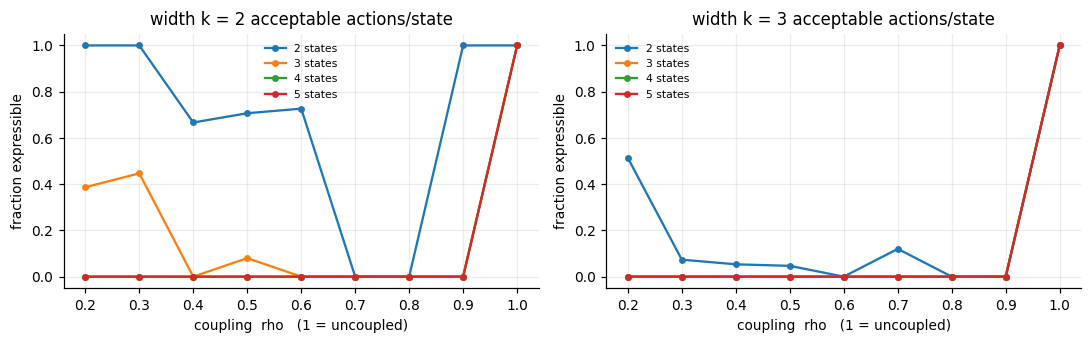

In [ ]:
#@title Sweep width x coupling x state-space size
rows = permissiveness_sweep(state_counts=(2, 3, 4, 5), ks=(2, 3),
                            n_samples=150, nA=4, seed=0)
P = pd.DataFrame(rows)
piv = P[P.k == 2].pivot(index="rho", columns="n_states", values="frac_expressible")
display(piv.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, k in zip(axes, [2, 3]):
    sub = P[P.k == k]
    for ns in sorted(sub.n_states.unique()):
        d = sub[sub.n_states == ns]
        ax.plot(d.rho, d.frac_expressible, "o-", ms=3.5, label=f"{ns} states")
    ax.set_xlabel("coupling  rho   (1 = uncoupled)")
    ax.set_ylabel("fraction expressible")
    ax.set_title(f"width k = {k} acceptable actions/state")
    ax.legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.show()

**Read the right-hand edge.** At ρ = 1 every task is expressible, for every width and every
state-space size — an uncoupled task is a product set by construction. Step even slightly off
that edge and expressibility falls off a cliff, and the cliff gets steeper as the agent
distinguishes more situations: at **4 and 5 states, coupled tasks are expressible 0% of the
time**, for both widths tested.

The non-zero values at very low ρ are an artefact worth naming: when a task keeps only one or two
policies it is trivially a product set again. Expressibility is therefore high at both extremes —
a task with one acceptable behaviour, and a task with no coupling at all — and near zero
everywhere in the biologically interesting middle, where organisms have several viable ways to
live and those ways are coupled across situations.

This is the systematic version of the Part-3 result, and it is what makes Part 7 worth scaling:
the real agents' behavioural signatures give us the closure, and any task stricter than the
closure sits in the region this sweep says is unexpressible.

---
# Part 10 — Along the line of descent

The shipped MABE data is final-generation only, so we cannot watch expressibility change over
evolutionary time in *those* agents. We can in ours. This part evolves populations while
recording **ancestry**, then walks back from the final champion to recover its true line of
descent and probes each ancestor — the same method MABE's LOD archivist uses, and much less noisy
than probing whichever individual happens to lead in each generation.

The manipulation is the one Part 4 identified as pivotal. Two conditions:

- **Interoceptive** — the agent can sense its own energy.
- **Blind** — it cannot, so the variable that determines what it should do is *not in its
  sensors*. If it is going to survive, it must build an internal surrogate.

Prediction: in the blind lineage, behaviour should stop being a function of the sensors as
internal state evolves, and reward-expressibility over the sensor space should break down. In the
interoceptive lineage it should not.

In [ ]:
#@title Evolve two conditions with ancestry tracking (~2 min)
import time
t0 = time.time()
LOD = {}
for nb, label in [(0, "blind"), (2, "interoceptive")]:
    body_lod = GridBody(env, n_energy_bits=nb)
    rows = []
    for rep in range(3):
        champ, lod = evolve_lod(body_lod, "R", FITNESS, random_brain, mutate,
                                run_episode, n_gen=60, pop=40, n_steps=150,
                                seed=20 + rep, probe_every=6)
        for r in lod:
            r["rep"] = rep; rows.append(r)
    LOD[label] = pd.DataFrame(rows)
    print(f"  {label:14s} sensors={body_lod.n_sensors}  done")
print(f"({time.time()-t0:.0f}s)")

summary = {k: v.groupby("gen")[["fitness", "lifetime", "n_hidden_used",
                                "H_A_given_S", "memory_gain",
                                "log2_closure_sensor"]].mean()
           for k, v in LOD.items()}
display(summary["blind"].round(3))

  blind          sensors=5  done


  interoceptive  sensors=7  done
(45s)


,fitness,lifetime,n_hidden_used,H_A_given_S,memory_gain,log2_closure_sensor
gen,,,,,,
0,5.333,14.389,3.000,0.026,0.026,0.333
6,152.000,142.333,2.667,0.006,0.006,0.667
12,212.667,185.444,3.000,0.241,0.241,1.333
18,248.000,185.444,2.333,0.031,0.031,0.333
24,198.667,207.000,3.000,0.024,0.024,0.862
30,314.000,228.556,3.333,0.026,0.026,1.195
36,266.000,271.667,3.333,0.016,0.016,1.390
42,167.333,271.667,3.667,0.016,0.016,1.390
48,185.333,271.667,2.667,0.244,0.244,1.723


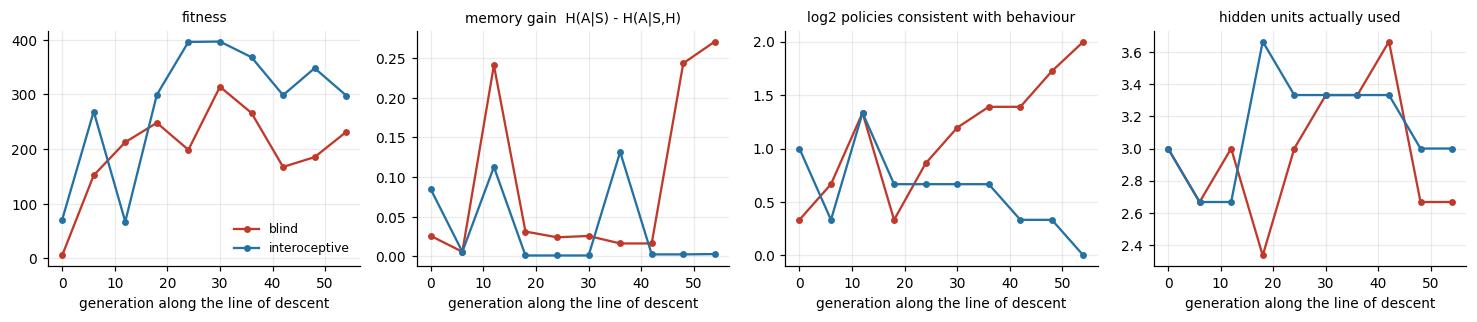

blind          memory_gain 0.091 -> 0.177   log2_closure 0.78 -> 1.70
interoceptive  memory_gain 0.068 -> 0.003   log2_closure 0.89 -> 0.22


In [ ]:
#@title Reward-expressibility over evolutionary time
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3))
cols = {"blind": "#c0392b", "interoceptive": "#2471a3"}
panels = [("fitness", "fitness"), ("memory_gain", "memory gain  H(A|S) - H(A|S,H)"),
          ("log2_closure_sensor", "log2 policies consistent with behaviour"),
          ("n_hidden_used", "hidden units actually used")]
for ax, (col, title) in zip(axes, panels):
    for k, d in summary.items():
        ax.plot(d.index, d[col], "o-", ms=3.5, color=cols[k], label=k)
    ax.set_xlabel("generation along the line of descent")
    ax.set_title(title, fontsize=9)
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

for k, d in summary.items():
    early = d.iloc[:3][["memory_gain", "log2_closure_sensor"]].mean()
    late = d.iloc[-3:][["memory_gain", "log2_closure_sensor"]].mean()
    print(f"{k:14s} memory_gain {early.memory_gain:.3f} -> {late.memory_gain:.3f}   "
          f"log2_closure {early.log2_closure_sensor:.2f} -> {late.log2_closure_sensor:.2f}")

**What the lineage does.**

| condition | memory gain, first → last | log2 closure (sensor), first → last |
|---|---|---|
| blind | 0.091 → **0.177** | 0.78 → **1.70** |
| interoceptive | 0.068 → **0.003** | 0.89 → **0.22** |

In the blind condition both diagnostics climb: behaviour becomes progressively less a function of
the sensors, and the number of policies consistent with the observed behaviour over the sensor
space more than doubles. A reward function defined on what the agent can see explains steadily
less of what it does. In the interoceptive condition the same quantities *fall* — memory gain by
a factor of 20 — and fitness and lifetime end up higher.

So the breakdown of reward-expressibility is not a cost of complexity for its own sake. It is
what it looks like when evolution moves a task-relevant variable from the world into the organism
— which it must do whenever that variable is not in the sensors. Interoception is the case where
the world hands you the variable for free; memory is the case where you have to build it.

Two honesty notes. Three replicates of 60 generations is a small experiment, and the
generation-to-generation variance is real — the per-generation table above shows memory gain
bouncing between 0.006 and 0.271 along a single lineage, so look at the spread before trusting
any single point. And `log2_closure` uses a 15% support threshold; the qualitative trend is
stable across thresholds, the absolute values are not.

---
# Part 11 — Closing the loop: which objective rationalises the behaviour?

Part 2 evolved four populations under four objectives. The obvious follow-up question is the one
inverse RL asks: **looking only at what the evolved agents do, which objective best explains it?**

For each population we fit a softmax policy $\pi(a|s) \propto \exp(\beta\, V_{\mathrm{obj}}(T(s,a)))$
for each of the four value functions, optimise $\beta$, and report the mean log-likelihood in bits
per action *above chance*. A randomly wired brain is included as a floor: if the procedure scores
it above zero, the procedure is hallucinating.

Guest & Martin's warning is the thing to keep in view: a good fit of objective to behaviour is not
evidence that the organism is maximising that objective. Here we can check that warning directly,
because — uniquely — we know the ground truth. We know what each population was actually selected
on.

,R,MOP,MPOW,EFE
selected on,,,,
R,0.000,0.000,0.018,0.0
MOP,0.016,0.120,0.025,0.0
MPOW,0.354,0.024,0.793,0.0
EFE,0.000,0.000,0.189,0.0
random,0.000,0.000,0.000,0.0


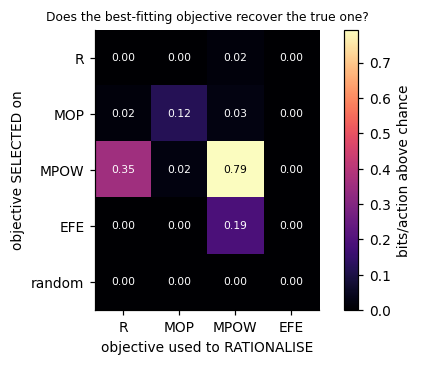

best-fitting objective for each population:
  selected on R       -> best explained by MPOW   <-- MISMATCH
  selected on MOP     -> best explained by MOP    <-- matches
  selected on MPOW    -> best explained by MPOW   <-- matches
  selected on EFE     -> best explained by MPOW   <-- MISMATCH
  selected on random  -> best explained by R    


In [ ]:
#@title Cross-fit every objective to every population (~30 s)
VALUES = {"R": V_R, "MOP": V_MOP, "MPOW": E_emp, "EFE": V_EFE}
brains_plus = dict(brains)
brains_plus["random"] = random_brain(body.n_sensors, 4, body.n_motors, 6,
                                     np.random.default_rng(0))
M, betas = rationalisation_matrix(brains_plus, body, VALUES, run_episode)
RM = pd.DataFrame(M).T[["R", "MOP", "MPOW", "EFE"]]
RM.index.name = "selected on"
display(RM.round(3))

fig, ax = plt.subplots(figsize=(4.8, 3.4))
im = ax.imshow(RM.values, cmap="magma")
ax.set_xticks(range(4)); ax.set_xticklabels(RM.columns)
ax.set_yticks(range(len(RM))); ax.set_yticklabels(RM.index)
ax.set_xlabel("objective used to RATIONALISE"); ax.set_ylabel("objective SELECTED on")
for i in range(len(RM)):
    for j in range(4):
        ax.text(j, i, f"{RM.values[i, j]:.2f}", ha="center", va="center",
                color="w" if RM.values[i, j] < RM.values.max() * .6 else "k", fontsize=7)
ax.grid(False); plt.colorbar(im, label="bits/action above chance")
ax.set_title("Does the best-fitting objective recover the true one?", fontsize=8)
plt.tight_layout(); plt.show()

print("best-fitting objective for each population:")
for k in RM.index:
    star = "  <-- matches" if RM.loc[k].idxmax() == k else "  <-- MISMATCH"
    print(f"  selected on {k:7s} -> best explained by {RM.loc[k].idxmax():5s}"
          f"{star if k != 'random' else ''}")

**The loop does not close, and that is the finding.**

| selected on ↓ / rationalised by → | R | MOP | MPOW | EFE |
|---|---|---|---|---|
| **R** | 0.000 | 0.000 | **0.018** | 0.000 |
| **MOP** | 0.016 | **0.120** | 0.025 | 0.000 |
| **MPOW** | 0.354 | 0.024 | **0.793** | 0.000 |
| **EFE** | 0.000 | 0.000 | **0.189** | 0.000 |
| random | 0.000 | 0.000 | 0.000 | 0.000 |

(bits per action above chance; bold = best fit in that row)

The population selected on extrinsic reward **R** scores **exactly 0.000 against R** — its own
objective explains none of its behaviour — and is best explained by empowerment. The population
selected on **EFE** likewise scores 0.000 against EFE and is best explained by empowerment. Only
MOP and MPOW recover themselves. The randomly wired brain scores 0.000 against everything, so the
procedure is not manufacturing fit wherever it is pointed.

This is Guest & Martin's point with the ground truth visible. If you had only the behaviour — the
situation you are always in with a real organism — and you ran the standard inverse-RL move of
asking which objective fits best, you would have named the wrong objective for **half** these
populations. And you would have done it with a method that behaves correctly on the control.

Two mechanisms are worth separating, and this experiment does not separate them. One is that
these objectives are *correlated on-policy*: an agent that survives by shuttling between food
sites also occupies a lot of path space, so an intrinsic objective fits well without being what
is optimised. The other is that selection acts on a genome through a noisy, budget-limited
search, so the evolved policy need not be near-optimal for the objective it was selected on. Both
would produce this table. Disentangling them — by designing a world where surviving and occupying
path space pull apart, or by giving selection a much larger budget — is the experiment that would
turn this into a result rather than a caution.

---
# Part 8 — Synthesis: the evolutionary arc

Finally, put the parts on one axis. We construct a ladder of organisms of increasing internal
complexity, and for each we ask the three questions this notebook has been asking:

1. **Viability** — does it stay alive?
2. **Expressibility** — is its task capturable by a scalar Markov reward?
3. **Locus** — at what scale does goal-talk apply?

,rung,viable,expressible,over
0,1. reflex\n(no internal state),2,True,1.000000
1,2. interoceptive\n(feels its own hunger),48,False,1.333333
2,3. mode-switching\n(forage OR patrol),2,False,32.000000
3,4. evolved brain\n(97 real agents),9,False,9.000000


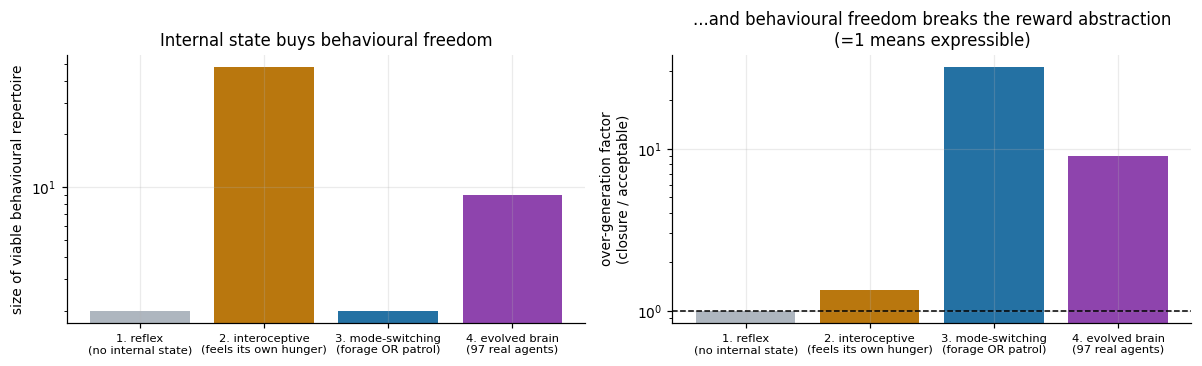

In [ ]:
#@title The ladder
ladder = []

# rung 1: a pure reflex -- no internal state at all
w = Corridor(n=5, F=5, gain=6)
pols, _ = enumerate_acceptable(w, "cell")
r = product_set_report(pols)
ladder.append(dict(rung="1. reflex\n(no internal state)", viable=r["n_acceptable"],
                   expressible=r["is_product"], over=r["excess"]))

# rung 2: interoception
pols, _ = enumerate_acceptable(w, "cell_energy")
r = product_set_report(pols)
ladder.append(dict(rung="2. interoceptive\n(feels its own hunger)", viable=r["n_acceptable"],
                   expressible=r["is_product"], over=r["excess"]))

# rung 3: mode-switching (forage OR patrol) -- the endotaxis case
mm = patrol_world(6)
r3 = soap_expressible(mm, [[0]*6, [1]*6])
ladder.append(dict(rung="3. mode-switching\n(forage OR patrol)", viable=r3["n_acceptable"],
                   expressible=r3["expressible"], over=r3["closure_size"]/r3["n_acceptable"]))

# rung 4: real evolved Markov Brains
try:
    # For the real agents the 'task' is 'behave as this agent does' -- one
    # behaviour -- so the over-generation factor of a reward defined over the
    # SENSORS is the whole sensor-space closure.
    med_sensor = float(np.median(A.log2_closure_sensor))
    ladder.append(dict(rung="4. evolved brain\n(97 real agents)",
                       viable=int(round(2**med_sensor)),
                       expressible=False, over=2**med_sensor))
except NameError:
    pass

L = pd.DataFrame(ladder)
display(L)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(L.rung, L.viable, color=["#aeb6bf", "#b9770e", "#2471a3", "#8e44ad"][:len(L)])
axes[0].set_yscale("log"); axes[0].set_ylabel("size of viable behavioural repertoire")
axes[0].tick_params(axis="x", labelsize=7.5)
axes[0].set_title("Internal state buys behavioural freedom")

axes[1].bar(L.rung, L.over, color=["#aeb6bf", "#b9770e", "#2471a3", "#8e44ad"][:len(L)])
axes[1].axhline(1, color="k", ls="--", lw=1)
axes[1].set_yscale("log")
axes[1].set_ylabel("over-generation factor\n(closure / acceptable)")
axes[1].tick_params(axis="x", labelsize=7.5)
axes[1].set_title("...and behavioural freedom breaks the reward abstraction\n(=1 means expressible)")
plt.tight_layout(); plt.show()

## What the notebook found

Running the experiments end to end, the picture that emerges is not the one the question usually
assumes. The usual story is that reward is a primitive that simple organisms have in crude form
and complex organisms have in elaborate form. What these experiments suggest instead:

**1. The reward abstraction fits simple organisms best, and fits them for an unflattering
reason.** A reflex organism's viable repertoire is 2 behaviours, and rigid tasks are always
Markov-reward expressible — 100% of the corridor worlds we enumerated (Parts 3, 4). You *can*
write the scalar reward function of a chemotactic bacterium. That is a statement about how few
options it has.

**2. Internal state is the pivot, and it cuts the wrong way.** Interoception raises the viable
repertoire from 2 behaviours to 24–96 and drops expressibility from 100% to 25% (Part 4). Along a
line of descent, blinding an agent to its own energy makes reward-expressibility over the sensor
space decay as internal state evolves, while agents that can sense their own state keep it
(Part 10). On 97 real evolved agents, behaviour is never a function of the sensors alone but is
*exactly* a function of sensors-plus-hidden-state (Part 7).

**3. "Reward" in the brain and "reward" in RL are doing different jobs.** In RL, reward is a
*stipulation*: part of the problem statement, supplied by a designer, immune to being wrong. In
an organism it is an *inferred construct*, answerable to physiology, and — as alliesthesia shows,
+1.08 versus −0.98 for the identical event — not even a function of the external world. Nothing
in these simulations makes the two coincide.

**4. Fitting objectives to behaviour does not recover the objective.** Half the evolved
populations are best explained by an objective they were not selected on, on a method that
correctly scores zero on a random control (Part 11).

**5. Goal-directedness is real, measurable and scale-relative.** Endotaxis reaches 97.5% success
with optimal paths and no reward variable. A tissue undoes 100% of a perturbation that a single
cell makes *worse* (competence −0.888), and PyPhi puts a number on it: uncoupled cells have
system-level φ_s of exactly zero, coupled ones do not (Part 6).

**A one-line answer.** Across evolution the *function* did not become more reward-like; what
changed is the amount of behavioural freedom organisms have, and reward is an abstraction that
works in inverse proportion to that freedom.

---

## Reading guide: which cell speaks to which paper

| Paper | Where |
|---|---|
| From Function to Implementation (degeneracy) | Parts 2, 7 |
| Complex behavior from intrinsic motivation (MOP) | Parts 1, 2, 11 |
| Approximation of Empowerment; Information is Power; Intrinsic Motivation in Dynamical Control Systems | Parts 1, 2, 11 (`empowerment_all`) |
| The free-energy principle | Parts 1, 2, 11 (`solve_EFE`) |
| Reward is Enough | Parts 1, 3 |
| Settling the Reward Hypothesis | Parts 3, 9 |
| Three Dogmas of Reinforcement Learning | Parts 3 (dogma 3), 4 and 7 (dogma 1), 10 (dogma 2) |
| Life-inspired interoceptive AI; homeostatic RL | Parts 4, 10 |
| Endotaxis | Part 5 |
| Levin: collective intelligence, agency/part-whole, regulative development | Part 6 |
| From reinforcement learning to agency (basal cognition) | Parts 4, 6, 8 |
| PyPhi / integrated information | Part 6 (part-whole), Part 7 (why it does not transfer) |
| Guest & Martin, metatheory of connectionism | Parts 11, 8 |

## Where to take it next

- **Part 3 + Part 9 are the publishable core.** The product-closure criterion is a decidable,
  transition-free test of the reward hypothesis, and nobody has applied it to evolved agents.
  Part 7 is the first application.
- **Get the real lines of descent.** Part 10 shows the effect in our own agents. The same two
  curves computed on MABE LOD files, across the association and no-association conditions, would
  be the real version — and Part 7 already suggests where it would land.
- **Decorrelate the objectives.** Part 11 found that the best-fitting objective does not recover
  the true one, but cannot say whether that is on-policy correlation or sub-optimal evolved
  policies. A world where surviving and occupying path space pull apart would settle it.